# DATA ANALYTHIC PROGRAMMING PROJECT
# GROUP MEMBERS
**NAME:**<br>
1) IMAN ABADI BIN MOHD NIZWAN - <i>A23CS0084</i><br>
2) MOHAMED ALIF FATHI BIN ABDUL LATIF - <i>A23CS0112</i><br>
3) MUHAMMAD AFIQ DANIAL BIN ROZAIDIE - <i>A23CS0117</i>

### Video Link: https://drive.google.com/file/d/1NiGLavyoQyQZVi5puGBNVp2ekkzvE_ku/view?usp=sharing

# <u>Phase I: DATA PREPARATION AND CLEANING</u>

<h2><u>Dataset Introduction</u></h2>

The main data that we used in this project are cars_2025.csv and FuelCosumption.csv.
The FuelConsumption.csv dataset contain an attributes of a vehicle, including MODELYEAR, MAKE, MODEL, VEHICLECLASS, ENGINESIZE, CYLINDERS, TRANSMISSION, FUELTYPE, as well as multiple fuel consumption metrics such as FUELCONSUMPTION_CITY, FUELCONSUMPTION_HWY, FUELCONSUMPTION_COMB, FUELCONSUMPTION_COMB_MPG, and CO2EMISSIONS.
On the other hand, cars_2025.csv focus on the vehicle registration information or a model feature like date_reg, type, maker, model, colour, fuel, and state. These dataset will use to combined and analyze to explore the relationship between these datasets on vehicle specifications, fuel consumption, and carbon emissions.

<h2><u>Research Question</u></h2>

- How do different car makes and fuel types, as registered in 2025 across various states, influence average carbon emissions, and what patterns can be uncovered through merging a maker and a model of the cars and analyzing vehicle registration data with technical fuel consumption data?
- How can vehicle attributes and registration data be used to classify or cluster car makes and models by their carbon emissions, and what patterns emerge through summary analytics and visual exploration of the 2025 car market?

<h2><u>Data Cleaning and Preparation</u></h2>

1) Drop duplicates <br>
Duplicate rows were identified and removed from both datasets to ensure that each car record is unique and to prevent skewed analysis results. Duplicated were checked by using df.drop_duplicates(inplace = True) function, to drop the same row infortmation in cars_2025. 

3) Drop biased data / null values <br>
Rows containing missing values or incomplete records were removed to eliminate potential bias and maintain the integrity of the analysis. 'Rakan Niaga' row will be removed from the colums state in cars_2025 due to the biased data that have approximately 80% from the entire row in cars dataset.

4) Rename columns <br>
The 'maker' and 'model' columns in the Cars2025 dataset were renamed as 'MAKER MODEL' by using df.rename() function to ensure consistency with the FuelConsumption dataset for accurate merging.

5) Remove special characters <br>
Special characters were removed from the 'MAKER' and 'MODEL' fields to standardize naming conventions and avoid mismatches during data integration.

6) Mapping <br>
A mapping process or using df.map() function was applied to align and match categorical values, such as maker, model and fuel types between the two datasets to ensure consistency.

7) Merging <br>
The cleaned cars_2025 and FuelConsumption datasets were merged with the help of pandas function (pd.merge()) based on common vehicle attributes, enabling a comprehensive view that combines registration and emission information.

8) Data matching <br>
Post-merge data matching was performed to validate the integrity of the merged dataset, ensuring that records from both sources correctly correspond to the same vehicle entities.

In [1]:
# Import
import numpy as np
import pandas as pd
#pd.set_option('display.max_rows', None)

df = pd.read_csv('cars_2025.csv')
df2 = pd.read_csv('FuelConsumption.csv')

In [2]:
# Clean data 
df.drop_duplicates(inplace = True)
df.drop(df[df['state'] == 'Rakan Niaga'].index, inplace=True)

In [3]:
# Rename columns and match naming of both dataframe
df.rename(columns={'maker': 'MAKER', 'model':'MODEL','fuel':'fuel_type'}, inplace=True)
df2.rename(columns={'MAKE': 'MAKER'}, inplace=True)
df['MAKER'] = df['MAKER'].str.upper()
df['MAKER'] = df['MAKER'].str.replace(r'\s+', '-', regex=True)
df2['MAKER'] = df2['MAKER'].str.replace(r'\s+', '-', regex=True)

In [4]:
df2['FUELTYPE'].value_counts()

FUELTYPE
X    514
Z    434
E     92
D     27
Name: count, dtype: int64

In [5]:
df['fuel_type'].value_counts()

fuel_type
petrol           15589
greendiesel       2526
electric          1851
hybrid_petrol     1526
diesel            1502
Name: count, dtype: int64

In [6]:
# Mapping
fuel_map = {'Z': 'petrol', 'X': 'petrol', 'D': 'diesel', 'E': 'electric'}
df2['fuel_type'] = df2['FUELTYPE'].map(fuel_map)

# Add hybrid for models with "HYBRID" in name
hybrid_mask = df2['MODEL'].str.contains('HYBRID', na=False)
petrol_mask = df2['FUELTYPE'].isin(['Z', 'X'])
diesel_mask = df2['FUELTYPE'] == 'D'

df2.loc[hybrid_mask & petrol_mask, 'fuel_type'] = 'hybrid_petrol'
df2.loc[hybrid_mask & diesel_mask, 'fuel_type'] = 'hybrid_diesel'

df2.drop('FUELTYPE', axis=1, inplace=True)
df2[['MODEL', 'fuel_type']]

,MODEL,fuel_type
0,ILX,petrol
1,ILX,petrol
2,ILX HYBRID,hybrid_petrol
3,MDX 4WD,petrol
4,RDX AWD,petrol
...,...,...
1062,XC60 AWD,petrol
1063,XC60 AWD,petrol
1064,XC70 AWD,petrol
1065,XC70 AWD,petrol


In [7]:
df2['fuel_type'].value_counts()

fuel_type
petrol           924
electric          92
diesel            27
hybrid_petrol     24
Name: count, dtype: int64

In [8]:
#Display df1
print(df['MAKER'].value_counts().sort_index())
print()
print(df['MODEL'].value_counts().sort_index())
print()
print(df['fuel_type'].value_counts().sort_index())

MAKER
ACURA               1
ALFA-ROMEO          1
ASTON-MARTIN        7
AUDI               66
BAW                 1
                 ... 
WESTSTAR-MAXUS     45
XINNENG             3
XPENG              75
ZEEKR             134
ZXAUTO              1
Name: count, Length: 76, dtype: int64

MODEL
009         125
1 Series     12
2 Series     16
2008         11
296          12
           ... 
i8            1
iX           11
iX1          25
iX2          55
iX3           5
Name: count, Length: 378, dtype: int64

fuel_type
diesel            1502
electric          1851
greendiesel       2526
hybrid_petrol     1526
petrol           15589
Name: count, dtype: int64


In [9]:
#Diplay df2
print(df2['MAKER'].value_counts().sort_index())
print()
print(df2['MODEL'].value_counts().sort_index())
print()
print(df2['fuel_type'].value_counts().sort_index())

MAKER
ACURA            12
ASTON-MARTIN      7
AUDI             49
BENTLEY           8
BMW              64
BUICK            16
CADILLAC         32
CHEVROLET        86
CHRYSLER         19
DODGE            39
FIAT             10
FORD             90
GMC              49
HONDA            21
HYUNDAI          24
INFINITI         21
JAGUAR           22
JEEP             31
KIA              33
LAMBORGHINI       3
LAND-ROVER       19
LEXUS            22
LINCOLN          11
MASERATI          6
MAZDA            27
MERCEDES-BENZ    59
MINI             36
MITSUBISHI       16
NISSAN           33
PORSCHE          44
RAM              13
ROLLS-ROYCE       7
SCION             9
SMART             2
SRT               2
SUBARU           23
TOYOTA           49
VOLKSWAGEN       42
VOLVO            11
Name: count, dtype: int64

MODEL
1500 (MDS)         2
1500 4X4 (MDS)     2
1500 4X4 DIESEL    1
1500 4X4 FFV       2
1500 DIESEL        1
                  ..
Z4 sDRIVE35is      1
iQ                 1
tC           

In [10]:
print(df.isnull().sum())
print(df2.isnull().sum())

date_reg     0
type         0
MAKER        0
MODEL        0
colour       0
fuel_type    0
state        0
dtype: int64
MODELYEAR                   0
MAKER                       0
MODEL                       0
VEHICLECLASS                0
ENGINESIZE                  0
CYLINDERS                   0
TRANSMISSION                0
FUELCONSUMPTION_CITY        0
FUELCONSUMPTION_HWY         0
FUELCONSUMPTION_COMB        0
FUELCONSUMPTION_COMB_MPG    0
CO2EMISSIONS                0
fuel_type                   0
dtype: int64


In [11]:
df_combine = pd.merge(df2,df, on=['MAKER','fuel_type'], how = 'inner')

In [12]:
df_combine.isnull().sum()

MODELYEAR                   0
MAKER                       0
MODEL_x                     0
VEHICLECLASS                0
ENGINESIZE                  0
CYLINDERS                   0
TRANSMISSION                0
FUELCONSUMPTION_CITY        0
FUELCONSUMPTION_HWY         0
FUELCONSUMPTION_COMB        0
FUELCONSUMPTION_COMB_MPG    0
CO2EMISSIONS                0
fuel_type                   0
date_reg                    0
type                        0
MODEL_y                     0
colour                      0
state                       0
dtype: int64

In [13]:
df_combine.dropna(inplace=True)

In [14]:
df_combine

,MODELYEAR,MAKER,MODEL_x,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS,fuel_type,date_reg,type,MODEL_y,colour,state
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,9.9,6.7,8.5,33,196,petrol,2025-02-03,motokar_pelbagai_utiliti,MDX,white,W.P. Kuala Lumpur
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,11.2,7.7,9.6,29,221,petrol,2025-02-03,motokar_pelbagai_utiliti,MDX,white,W.P. Kuala Lumpur
2,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,12.7,9.1,11.1,25,255,petrol,2025-02-03,motokar_pelbagai_utiliti,MDX,white,W.P. Kuala Lumpur
3,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,12.1,8.7,10.6,27,244,petrol,2025-02-03,motokar_pelbagai_utiliti,MDX,white,W.P. Kuala Lumpur
4,2014,ACURA,RLX,MID-SIZE,3.5,6,AS6,11.9,7.7,10.0,28,230,petrol,2025-02-03,motokar_pelbagai_utiliti,MDX,white,W.P. Kuala Lumpur
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385096,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6,AS6,12.9,9.3,11.3,25,260,petrol,2025-03-27,motokar,S60,white,W.P. Kuala Lumpur
385097,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6,AS6,12.9,9.3,11.3,25,260,petrol,2025-04-08,jip,XC40,white,Selangor
385098,2014,VOLVO,XC90 AWD,SUV - STANDARD,3.2,6,AS6,14.9,10.2,12.8,22,294,petrol,2025-01-10,motokar,S60,silver,Perak
385099,2014,VOLVO,XC90 AWD,SUV - STANDARD,3.2,6,AS6,14.9,10.2,12.8,22,294,petrol,2025-03-27,motokar,S60,white,W.P. Kuala Lumpur


In [15]:
df_combine[['MAKER', 'MODEL_y', 'MODEL_x', 'fuel_type']]

,MAKER,MODEL_y,MODEL_x,fuel_type
0,ACURA,MDX,ILX,petrol
1,ACURA,MDX,ILX,petrol
2,ACURA,MDX,MDX 4WD,petrol
3,ACURA,MDX,RDX AWD,petrol
4,ACURA,MDX,RLX,petrol
...,...,...,...,...
385096,VOLVO,S60,XC70 AWD,petrol
385097,VOLVO,XC40,XC70 AWD,petrol
385098,VOLVO,S60,XC90 AWD,petrol
385099,VOLVO,S60,XC90 AWD,petrol


In [16]:
# Normalize model
df_combine['MODEL_x_norm'] = df_combine['MODEL_x'].str.lower().str.strip()
df_combine['MODEL_y_norm'] = df_combine['MODEL_y'].str.lower().str.strip()

df_combine['MODEL_MATCHED'] = ''

# Match rows MODEL_y and MODEL_x and create a new column MODEL_MATCHED
for i in range(len(df_combine)):
    if pd.notna(df_combine.loc[i, 'MODEL_y_norm']) and df_combine.loc[i, 'MODEL_y_norm'] in df_combine.loc[i, 'MODEL_x_norm']:
        df_combine.loc[i, 'MODEL_MATCHED'] = df_combine.loc[i, 'MODEL_y']

df_combine[['MODEL_x', 'MODEL_y', 'MODEL_MATCHED']]


,MODEL_x,MODEL_y,MODEL_MATCHED
0,ILX,MDX,
1,ILX,MDX,
2,MDX 4WD,MDX,MDX
3,RDX AWD,MDX,
4,RLX,MDX,
...,...,...,...
385096,XC70 AWD,S60,
385097,XC70 AWD,XC40,
385098,XC90 AWD,S60,
385099,XC90 AWD,S60,


In [17]:
df_combine.isnull().sum()

MODELYEAR                   0
MAKER                       0
MODEL_x                     0
VEHICLECLASS                0
ENGINESIZE                  0
CYLINDERS                   0
TRANSMISSION                0
FUELCONSUMPTION_CITY        0
FUELCONSUMPTION_HWY         0
FUELCONSUMPTION_COMB        0
FUELCONSUMPTION_COMB_MPG    0
CO2EMISSIONS                0
fuel_type                   0
date_reg                    0
type                        0
MODEL_y                     0
colour                      0
state                       0
MODEL_x_norm                0
MODEL_y_norm                0
MODEL_MATCHED               0
dtype: int64

In [18]:
df_combine['MODEL_MATCHED'].value_counts()

MODEL_MATCHED
               371599
Cooper           2340
Civic            1572
RX               1239
911 Carrera      1008
                ...  
Sienna              2
RS7                 1
Mulsanne            1
MDX                 1
Vanquish            1
Name: count, Length: 86, dtype: int64

In [19]:
#Drop rows where MODEL_MATCHED is empty
df_combine.drop(df_combine[df_combine['MODEL_MATCHED'] == ''].index, inplace=True)

In [20]:
df_combine

,MODELYEAR,MAKER,MODEL_x,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,...,CO2EMISSIONS,fuel_type,date_reg,type,MODEL_y,colour,state,MODEL_x_norm,MODEL_y_norm,MODEL_MATCHED
2,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,12.7,9.1,11.1,...,255,petrol,2025-02-03,motokar_pelbagai_utiliti,MDX,white,W.P. Kuala Lumpur,mdx 4wd,mdx,MDX
25,2014,ASTON-MARTIN,V8 VANTAGE,TWO-SEATER,4.7,8,AM7,17.4,11.3,14.7,...,338,petrol,2025-01-07,motokar,Vantage,orange,W.P. Kuala Lumpur,v8 vantage,vantage,Vantage
32,2014,ASTON-MARTIN,V8 VANTAGE,TWO-SEATER,4.7,8,M6,18.1,12.2,15.4,...,354,petrol,2025-01-07,motokar,Vantage,orange,W.P. Kuala Lumpur,v8 vantage,vantage,Vantage
39,2014,ASTON-MARTIN,V8 VANTAGE S,TWO-SEATER,4.7,8,AM7,17.4,11.3,14.7,...,338,petrol,2025-01-07,motokar,Vantage,orange,W.P. Kuala Lumpur,v8 vantage s,vantage,Vantage
46,2014,ASTON-MARTIN,V8 VANTAGE S,TWO-SEATER,4.7,8,M6,18.1,12.2,15.4,...,354,petrol,2025-01-07,motokar,Vantage,orange,W.P. Kuala Lumpur,v8 vantage s,vantage,Vantage
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385069,2014,VOLVO,S60,COMPACT,2.5,5,AS6,11.3,7.8,9.7,...,223,petrol,2025-03-27,motokar,S60,white,W.P. Kuala Lumpur,s60,s60,S60
385071,2014,VOLVO,S60 AWD,COMPACT,2.5,5,AS6,11.6,8.3,10.1,...,232,petrol,2025-01-10,motokar,S60,silver,Perak,s60 awd,s60,S60
385072,2014,VOLVO,S60 AWD,COMPACT,2.5,5,AS6,11.6,8.3,10.1,...,232,petrol,2025-03-27,motokar,S60,white,W.P. Kuala Lumpur,s60 awd,s60,S60
385074,2014,VOLVO,S60 AWD,COMPACT,3.0,6,AS6,13.2,9.5,11.5,...,264,petrol,2025-01-10,motokar,S60,silver,Perak,s60 awd,s60,S60


In [21]:
df_combine.reset_index(inplace = True)

In [22]:
df_combine.drop(['index'], inplace = True ,axis = 1)

In [23]:
df_combine

,MODELYEAR,MAKER,MODEL_x,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,...,CO2EMISSIONS,fuel_type,date_reg,type,MODEL_y,colour,state,MODEL_x_norm,MODEL_y_norm,MODEL_MATCHED
0,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,12.7,9.1,11.1,...,255,petrol,2025-02-03,motokar_pelbagai_utiliti,MDX,white,W.P. Kuala Lumpur,mdx 4wd,mdx,MDX
1,2014,ASTON-MARTIN,V8 VANTAGE,TWO-SEATER,4.7,8,AM7,17.4,11.3,14.7,...,338,petrol,2025-01-07,motokar,Vantage,orange,W.P. Kuala Lumpur,v8 vantage,vantage,Vantage
2,2014,ASTON-MARTIN,V8 VANTAGE,TWO-SEATER,4.7,8,M6,18.1,12.2,15.4,...,354,petrol,2025-01-07,motokar,Vantage,orange,W.P. Kuala Lumpur,v8 vantage,vantage,Vantage
3,2014,ASTON-MARTIN,V8 VANTAGE S,TWO-SEATER,4.7,8,AM7,17.4,11.3,14.7,...,338,petrol,2025-01-07,motokar,Vantage,orange,W.P. Kuala Lumpur,v8 vantage s,vantage,Vantage
4,2014,ASTON-MARTIN,V8 VANTAGE S,TWO-SEATER,4.7,8,M6,18.1,12.2,15.4,...,354,petrol,2025-01-07,motokar,Vantage,orange,W.P. Kuala Lumpur,v8 vantage s,vantage,Vantage
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13497,2014,VOLVO,S60,COMPACT,2.5,5,AS6,11.3,7.8,9.7,...,223,petrol,2025-03-27,motokar,S60,white,W.P. Kuala Lumpur,s60,s60,S60
13498,2014,VOLVO,S60 AWD,COMPACT,2.5,5,AS6,11.6,8.3,10.1,...,232,petrol,2025-01-10,motokar,S60,silver,Perak,s60 awd,s60,S60
13499,2014,VOLVO,S60 AWD,COMPACT,2.5,5,AS6,11.6,8.3,10.1,...,232,petrol,2025-03-27,motokar,S60,white,W.P. Kuala Lumpur,s60 awd,s60,S60
13500,2014,VOLVO,S60 AWD,COMPACT,3.0,6,AS6,13.2,9.5,11.5,...,264,petrol,2025-01-10,motokar,S60,silver,Perak,s60 awd,s60,S60


In [24]:
df_combine['fuel_type'].value_counts()

fuel_type
petrol           13444
hybrid_petrol       58
Name: count, dtype: int64

In [25]:
# Drop unnecessary columns
df_combine.drop(['MODEL_x_norm', 'MODEL_y_norm', 'MODEL_MATCHED', 'MODEL_y'], axis=1, inplace=True)
df_combine

,MODELYEAR,MAKER,MODEL_x,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS,fuel_type,date_reg,type,colour,state
0,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,12.7,9.1,11.1,25,255,petrol,2025-02-03,motokar_pelbagai_utiliti,white,W.P. Kuala Lumpur
1,2014,ASTON-MARTIN,V8 VANTAGE,TWO-SEATER,4.7,8,AM7,17.4,11.3,14.7,19,338,petrol,2025-01-07,motokar,orange,W.P. Kuala Lumpur
2,2014,ASTON-MARTIN,V8 VANTAGE,TWO-SEATER,4.7,8,M6,18.1,12.2,15.4,18,354,petrol,2025-01-07,motokar,orange,W.P. Kuala Lumpur
3,2014,ASTON-MARTIN,V8 VANTAGE S,TWO-SEATER,4.7,8,AM7,17.4,11.3,14.7,19,338,petrol,2025-01-07,motokar,orange,W.P. Kuala Lumpur
4,2014,ASTON-MARTIN,V8 VANTAGE S,TWO-SEATER,4.7,8,M6,18.1,12.2,15.4,18,354,petrol,2025-01-07,motokar,orange,W.P. Kuala Lumpur
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13497,2014,VOLVO,S60,COMPACT,2.5,5,AS6,11.3,7.8,9.7,29,223,petrol,2025-03-27,motokar,white,W.P. Kuala Lumpur
13498,2014,VOLVO,S60 AWD,COMPACT,2.5,5,AS6,11.6,8.3,10.1,28,232,petrol,2025-01-10,motokar,silver,Perak
13499,2014,VOLVO,S60 AWD,COMPACT,2.5,5,AS6,11.6,8.3,10.1,28,232,petrol,2025-03-27,motokar,white,W.P. Kuala Lumpur
13500,2014,VOLVO,S60 AWD,COMPACT,3.0,6,AS6,13.2,9.5,11.5,25,264,petrol,2025-01-10,motokar,silver,Perak


In [26]:
# Rename columns
df_combine.rename(columns={'MODEL_x': 'MODEL', 'fuel_type':'FUEL_TYPE', 'date_reg':'DATE_REG', 'type':'TYPE', 'colour':'COLOUR', 'state':'STATE' }, inplace=True)
df_combine
# Capital all uncapitalized letters
df_combine['FUEL_TYPE'] = df_combine['FUEL_TYPE'].str.upper()
df_combine['TYPE'] = df_combine['TYPE'].str.upper()
df_combine['COLOUR'] = df_combine['COLOUR'].str.upper()
df_combine['STATE'] = df_combine['STATE'].str.upper()
df_combine

,MODELYEAR,MAKER,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS,FUEL_TYPE,DATE_REG,TYPE,COLOUR,STATE
0,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,12.7,9.1,11.1,25,255,PETROL,2025-02-03,MOTOKAR_PELBAGAI_UTILITI,WHITE,W.P. KUALA LUMPUR
1,2014,ASTON-MARTIN,V8 VANTAGE,TWO-SEATER,4.7,8,AM7,17.4,11.3,14.7,19,338,PETROL,2025-01-07,MOTOKAR,ORANGE,W.P. KUALA LUMPUR
2,2014,ASTON-MARTIN,V8 VANTAGE,TWO-SEATER,4.7,8,M6,18.1,12.2,15.4,18,354,PETROL,2025-01-07,MOTOKAR,ORANGE,W.P. KUALA LUMPUR
3,2014,ASTON-MARTIN,V8 VANTAGE S,TWO-SEATER,4.7,8,AM7,17.4,11.3,14.7,19,338,PETROL,2025-01-07,MOTOKAR,ORANGE,W.P. KUALA LUMPUR
4,2014,ASTON-MARTIN,V8 VANTAGE S,TWO-SEATER,4.7,8,M6,18.1,12.2,15.4,18,354,PETROL,2025-01-07,MOTOKAR,ORANGE,W.P. KUALA LUMPUR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13497,2014,VOLVO,S60,COMPACT,2.5,5,AS6,11.3,7.8,9.7,29,223,PETROL,2025-03-27,MOTOKAR,WHITE,W.P. KUALA LUMPUR
13498,2014,VOLVO,S60 AWD,COMPACT,2.5,5,AS6,11.6,8.3,10.1,28,232,PETROL,2025-01-10,MOTOKAR,SILVER,PERAK
13499,2014,VOLVO,S60 AWD,COMPACT,2.5,5,AS6,11.6,8.3,10.1,28,232,PETROL,2025-03-27,MOTOKAR,WHITE,W.P. KUALA LUMPUR
13500,2014,VOLVO,S60 AWD,COMPACT,3.0,6,AS6,13.2,9.5,11.5,25,264,PETROL,2025-01-10,MOTOKAR,SILVER,PERAK


In [27]:
df_combine.set_index(['MAKER', 'MODEL'], inplace=True)
df_combine

MODELYEAR VEHICLECLASS  ENGINESIZE  CYLINDERS  \
MAKER        MODEL                                                         
ACURA        MDX 4WD            2014  SUV - SMALL         3.5          6   
ASTON-MARTIN V8 VANTAGE         2014   TWO-SEATER         4.7          8   
             V8 VANTAGE         2014   TWO-SEATER         4.7          8   
             V8 VANTAGE S       2014   TWO-SEATER         4.7          8   
             V8 VANTAGE S       2014   TWO-SEATER         4.7          8   
...                              ...          ...         ...        ...   
VOLVO        S60                2014      COMPACT         2.5          5   
             S60 AWD            2014      COMPACT         2.5          5   
             S60 AWD            2014      COMPACT         2.5          5   
             S60 AWD            2014      COMPACT         3.0          6   
             S60 AWD            2014      COMPACT         3.0          6   

                          TRANSMISSION  FUELCONSUMPTION_CITY  \
MAKER        MODEL                                             
ACURA        MDX 4WD               AS6                  12.7   
ASTON-MARTIN V8 VANTAGE            AM7                  17.4   
             V8 VANTAGE             M6                  18.1   
             V8 VANTAGE S          AM7                  17.4   
             V8 VANTAGE S           M6                  18.1   
...                                ...                   ...   
VOLVO        S60                   AS6                  11.3   
             S60 AWD               AS6                  11.6   
             S60 AWD               AS6                  11.6   
             S60 AWD               AS6                  13.2   
             S60 AWD               AS6                  13.2   

                           FUELCONSUMPTION_HWY  FUELCONSUMPTION_COMB  \
MAKER        MODEL                                                     
ACURA        MDX 4WD                       9.1                  11.1   
ASTON-MARTIN V8 VANTAGE                   11.3                  14.7   
             V8 VANTAGE                   12.2                  15.4   
             V8 VANTAGE S                 11.3                  14.7   
             V8 VANTAGE S                 12.2                  15.4   
...                                        ...                   ...   
VOLVO        S60                           7.8                   9.7   
             S60 AWD                       8.3                  10.1   
             S60 AWD                       8.3                  10.1   
             S60 AWD                       9.5                  11.5   
             S60 AWD                       9.5                  11.5   

                           FUELCONSUMPTION_COMB_MPG  CO2EMISSIONS FUEL_TYPE  \
MAKER        MODEL                                                            
ACURA        MDX 4WD                             25           255    PETROL   
ASTON-MARTIN V8 VANTAGE                          19           338    PETROL   
             V8 VANTAGE                          18           354    PETROL   
             V8 VANTAGE S                        19           338    PETROL   
             V8 VANTAGE S                        18           354    PETROL   
...                                             ...           ...       ...   
VOLVO        S60                                 29           223    PETROL   
             S60 AWD                             28           232    PETROL   
             S60 AWD                             28           232    PETROL   
             S60 AWD                             25           264    PETROL   
             S60 AWD                             25           264    PETROL   

                             DATE_REG                      TYPE  COLOUR  \
MAKER        MODEL                                                        
ACURA        MDX 4WD       2025-02-03  MOTOKAR_PELBAGAI_UTILITI   WHITE   
ASTON-MARTIN V8

In [28]:
df_combine.to_csv('cleaned.csv')

<h2><u>Conclusion for Phase I</u></h2>

In conclusion, this project unites two similar datasets cars_2025 and FuelConsumption to analyze vehicle features and registration data on fuel consumption and carbon emissions in the 2025 car market. An exhaustive exercise in data cleaning and preparation involving duplicate removal, null value handling, column normalization, and data mapping enabled the successful merger of the datasets to allow for meaningful and accurate analysis. This integration enables the exploration of key research questions around emission patterns by make, model, and fuel type, offering valuable insights into environmental impact and trends within vehicle registrations and specifications.

# <u>Phase II: DATA ANALYTICS, VISUALIZATION AND VIDEO RECORDING</u>

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

This cell reads a CSV file named "cleaned.csv" into a pandas DataFrame and then displays the DataFrame. The `df` variable will hold the entire dataset, which appears to contain information about vehicles, including details like make, model, model year, vehicle class, engine size, fuel consumption, CO2 emissions, and registration details.

The output shows a sample of the DataFrame, including column names and the first few rows of data, along with the total number of rows and columns.

In [30]:
df = pd.read_csv("cleaned.csv")
df

,MAKER,MODEL,MODELYEAR,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS,FUEL_TYPE,DATE_REG,TYPE,COLOUR,STATE
0,ACURA,MDX 4WD,2014,SUV - SMALL,3.5,6,AS6,12.7,9.1,11.1,25,255,PETROL,2025-02-03,MOTOKAR_PELBAGAI_UTILITI,WHITE,W.P. KUALA LUMPUR
1,ASTON-MARTIN,V8 VANTAGE,2014,TWO-SEATER,4.7,8,AM7,17.4,11.3,14.7,19,338,PETROL,2025-01-07,MOTOKAR,ORANGE,W.P. KUALA LUMPUR
2,ASTON-MARTIN,V8 VANTAGE,2014,TWO-SEATER,4.7,8,M6,18.1,12.2,15.4,18,354,PETROL,2025-01-07,MOTOKAR,ORANGE,W.P. KUALA LUMPUR
3,ASTON-MARTIN,V8 VANTAGE S,2014,TWO-SEATER,4.7,8,AM7,17.4,11.3,14.7,19,338,PETROL,2025-01-07,MOTOKAR,ORANGE,W.P. KUALA LUMPUR
4,ASTON-MARTIN,V8 VANTAGE S,2014,TWO-SEATER,4.7,8,M6,18.1,12.2,15.4,18,354,PETROL,2025-01-07,MOTOKAR,ORANGE,W.P. KUALA LUMPUR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13497,VOLVO,S60,2014,COMPACT,2.5,5,AS6,11.3,7.8,9.7,29,223,PETROL,2025-03-27,MOTOKAR,WHITE,W.P. KUALA LUMPUR
13498,VOLVO,S60 AWD,2014,COMPACT,2.5,5,AS6,11.6,8.3,10.1,28,232,PETROL,2025-01-10,MOTOKAR,SILVER,PERAK
13499,VOLVO,S60 AWD,2014,COMPACT,2.5,5,AS6,11.6,8.3,10.1,28,232,PETROL,2025-03-27,MOTOKAR,WHITE,W.P. KUALA LUMPUR
13500,VOLVO,S60 AWD,2014,COMPACT,3.0,6,AS6,13.2,9.5,11.5,25,264,PETROL,2025-01-10,MOTOKAR,SILVER,PERAK


Describe all the numerical values of the DataFrame `df`.

In [31]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,13502.0,13502.000000,13502.000000,13502.000000,13502.000000,13502.000000,13502.000000,13502.000000
mean,2014.0,2.523522,4.890535,10.667242,7.989231,9.460161,31.051178,217.620204
std,0.0,1.053215,1.294448,2.554513,1.577554,2.094047,6.023346,48.136101
min,2014.0,1.400000,4.000000,5.500000,5.600000,5.700000,15.000000,131.000000
25%,2014.0,1.600000,4.000000,8.600000,6.700000,7.800000,26.000000,179.000000
50%,2014.0,2.000000,4.000000,9.600000,7.800000,8.700000,32.000000,200.000000
75%,2014.0,3.500000,6.000000,12.500000,8.900000,10.900000,36.000000,251.000000
max,2014.0,6.800000,12.000000,22.800000,14.900000,19.000000,50.000000,437.000000


# Histogram Visualisation 

This Python code generates a **histogram** to visualize the **distribution of continuos values**, showing the raw frequency (counts) of those valus within different ranges.

### Display frequencies (raw counts) and generating the histogram using the .hist() functions
`n, bins, patches = ax.hist(df["CO2EMISSIONS"], bins=15, color="blue", alpha=0.7, edgecolor="black")` and unpcaks it into three different variables. The first parameter accepts the data values and the second parameter accepts the number of bins.

`ax.set_title("Distribution of CO2 Emissions (Frequency)")` sets the title of the graph

`ax.set_xlabel("CO2 Emissions")` and `ax.set_ylabel("Frequency (Count)") sets the label for x and y axis.

`plt.grid(axis='y', linestyle='--', alpha=0.7)` displays the grid of the graph form the prided axis and line style.




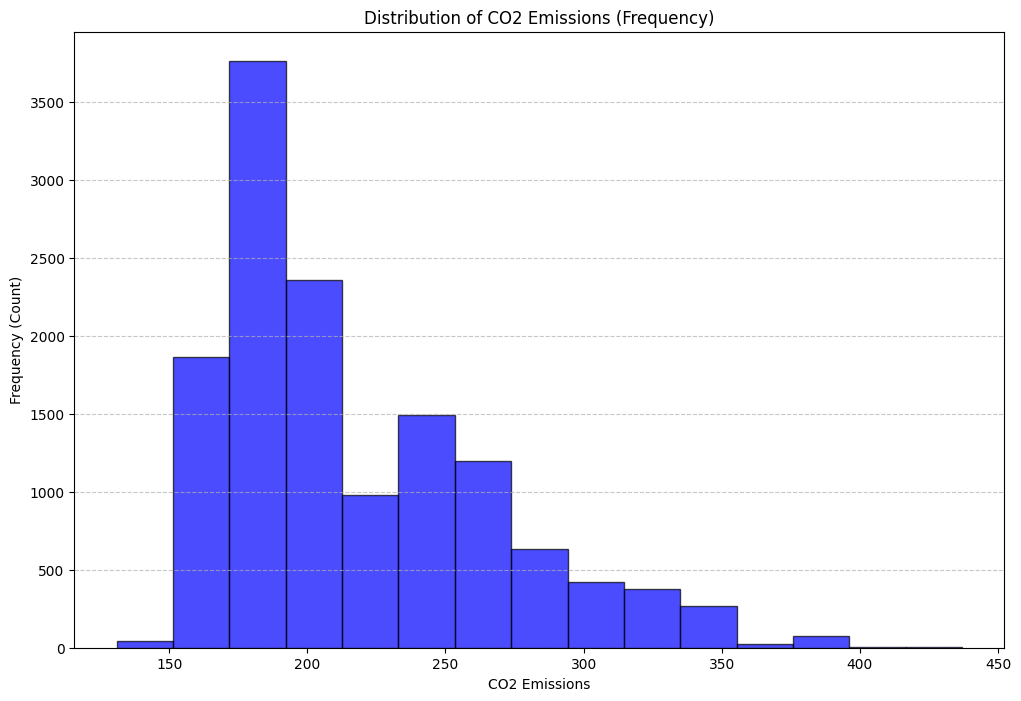

In [32]:
co2 = df["CO2EMISSIONS"]

fig, ax = plt.subplots(figsize=(12, 8))

n, bins, patches = ax.hist(co2, bins=15, color="blue", alpha=0.7, edgecolor="black")

ax.set_title("Distribution of CO2 Emissions (Frequency)")
ax.set_xlabel("CO2 Emissions")
ax.set_ylabel("Frequency (Count)") 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

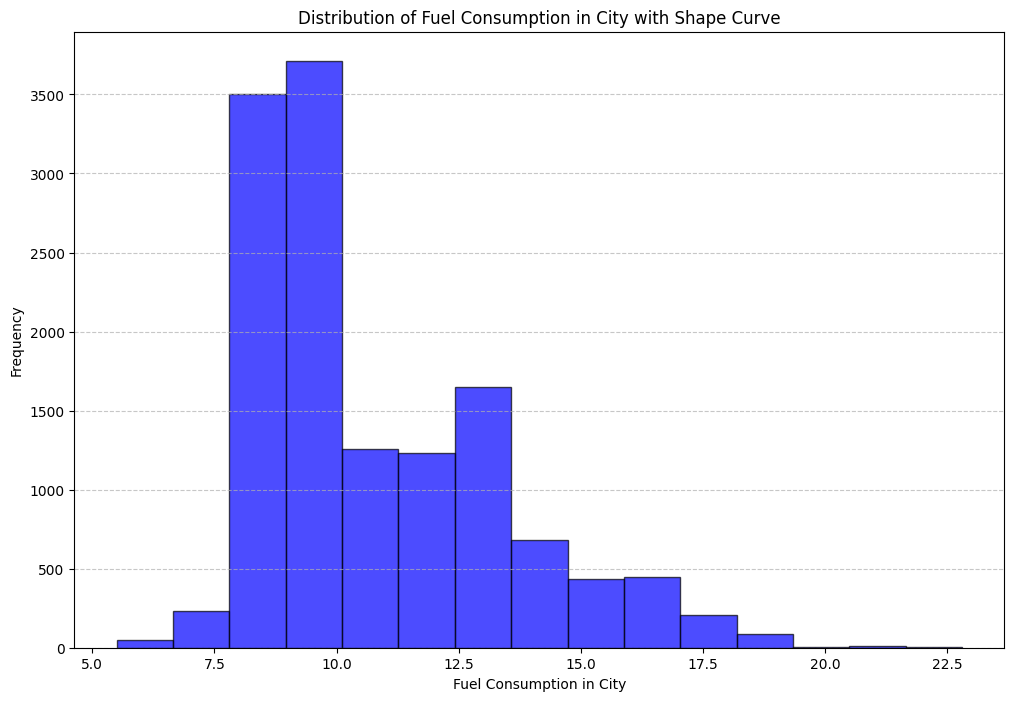

In [33]:
fuel_city = df["FUELCONSUMPTION_CITY"]

fig, ax = plt.subplots(figsize=(12, 8))

n, bins, patches = ax.hist(fuel_city, bins=15, color="blue", alpha=0.7, edgecolor="black")

ax.set_title("Distribution of Fuel Consumption in City with Shape Curve")
ax.set_xlabel("Fuel Consumption in City")
ax.set_ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

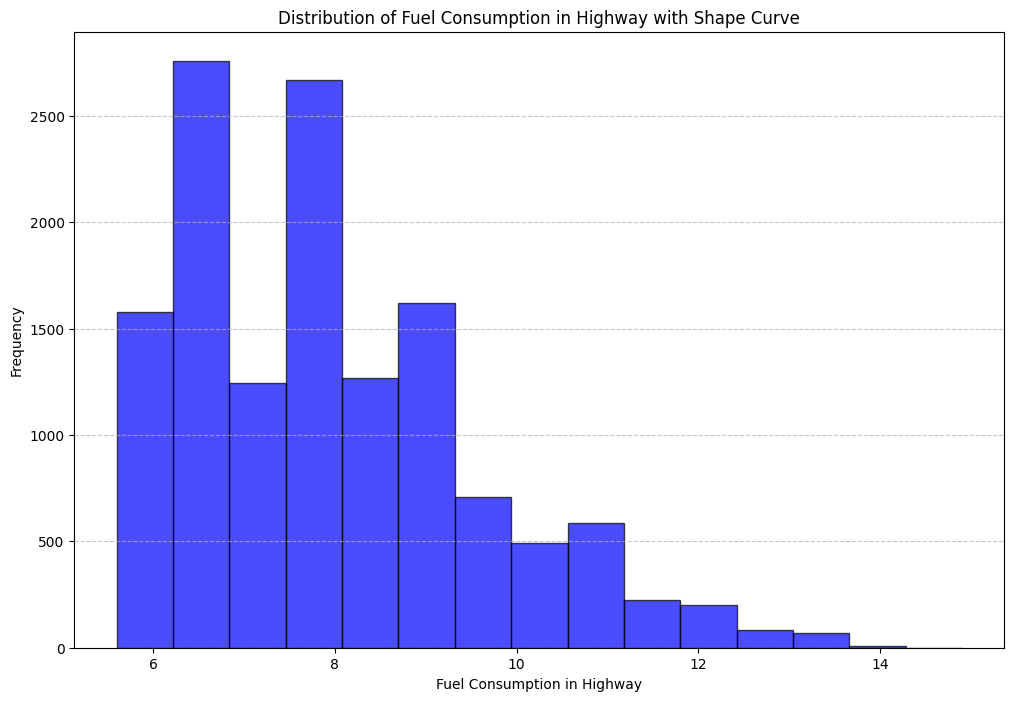

In [34]:
fuel_hwy = df["FUELCONSUMPTION_HWY"]

fig, ax = plt.subplots(figsize=(12, 8))

n, bins, patches = ax.hist(fuel_hwy, bins=15, color="blue", alpha=0.7, edgecolor="black")

ax.set_title("Distribution of Fuel Consumption in Highway with Shape Curve")
ax.set_xlabel("Fuel Consumption in Highway")
ax.set_ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

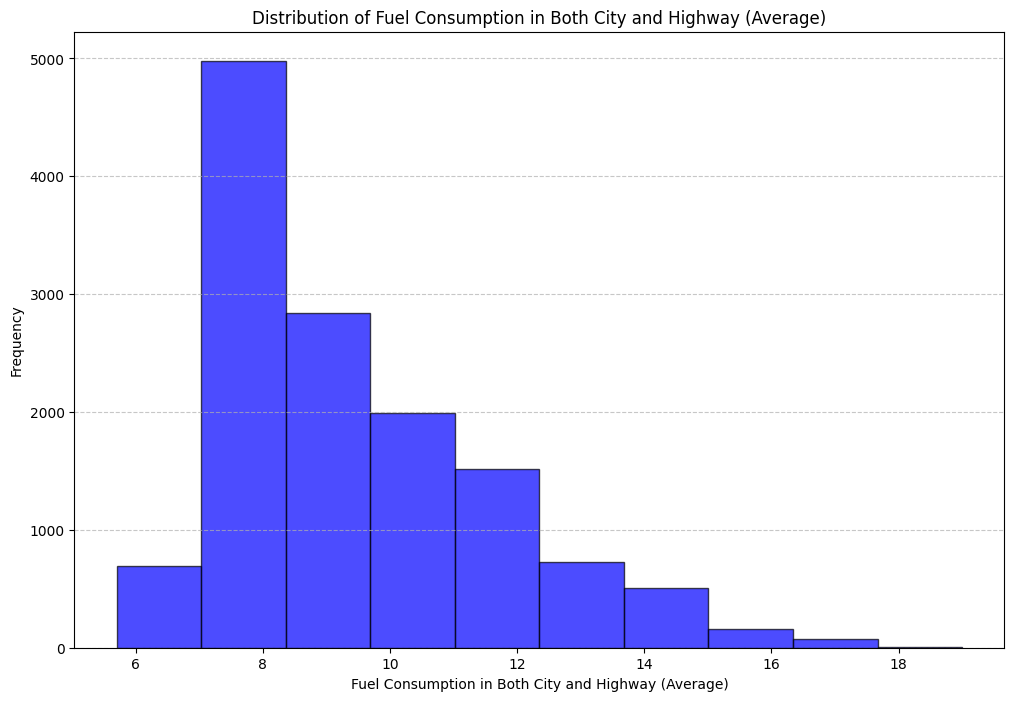

In [35]:
fuel_comb = df["FUELCONSUMPTION_COMB"]

fig, ax = plt.subplots(figsize=(12, 8))

n, bins, patches = ax.hist(fuel_comb, bins=10, color="blue", alpha=0.7, edgecolor = "black")

ax.set_title("Distribution of Fuel Consumption in Both City and Highway (Average)")
ax.set_xlabel("Fuel Consumption in Both City and Highway (Average)")
ax.set_ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

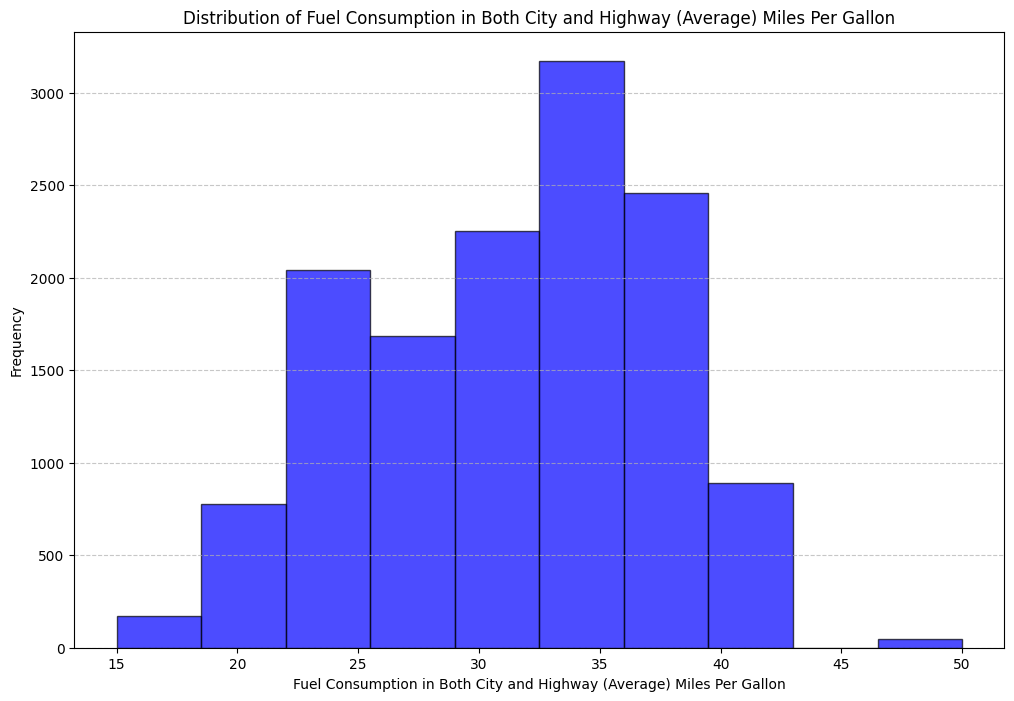

In [36]:
fuel_comb_mpg = df["FUELCONSUMPTION_COMB_MPG"]

fig, ax = plt.subplots(figsize=(12, 8))

n, bins, patches = ax.hist(fuel_comb_mpg, bins=10, color="blue", alpha=0.7, edgecolor="black")

ax.set_title("Distribution of Fuel Consumption in Both City and Highway (Average) Miles Per Gallon")
ax.set_xlabel("Fuel Consumption in Both City and Highway (Average) Miles Per Gallon")
ax.set_ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Scatter Plot Visualisation

This Python code performs a **linear regression analysis** to explore the relationship between `FUELCONSUMPTION_COMB_MPG` (fuel consumption in miles per gallon, combined) and `CO2EMISSIONS`. It then visualizes this relationship using a scatter plot and overlays the calculated linear regression line.

The code first extracts the `FUELCONSUMPTION_COMB_MPG` column into `x` (independent variable) and `CO2EMISSIONS` into `y` (dependent variable).


### Using the scipy library
`slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)` uses the scipy.linegress() function and unpacks is into 5 different values. The focus of this part is the R value.


A function `myfunc(x)` is defined using the calculated `slope` and `intercept` to represent the linear regression equation ($y = \text{slope} * x + \text{intercept}$).
`mymodel = list(map(myfunc, x))` applies this function to each value in the `x` (FUELCONSUMPTION_COMB_MPG) data to generate the predicted `CO2EMISSIONS` values according to the regression line.

### Scatter Plot Visualization:

`plt.scatter(x, y, marker = ".")` generates a **scatter plot** where each point represents a vehicle's `FUELCONSUMPTION_COMB_MPG` and its corresponding `CO2EMISSIONS`. The `marker="."` displays each data point as a small dot.

`plt.plot(x, mymodel, color='red', label=f'Linear Regression (R = {r_value:.3f}, R²={r_value**2:.3f})')` draws the **linear regression line** on top of the scatter plot.

`label=f'Linear Regression (R = {r_value:.3f}, R²={r_value**2:.3f})'` creates a label for the line in the legend, displaying the calculated R-value (correlation coefficient) and R-squared value (coefficient of determination), both formatted to three decimal places. The R-squared value indicates the proportion of the variance in `CO2EMISSIONS` that can be predicted from `FUELCONSUMPTION_COMB_MPG`.

`plt.legend()` displays the legend, which includes the label for the linear regression line.


### The significance of R-value
The R value is the Pearson correlation coefficient that measures the strength and direction of a linear relationship between two variables. It ranges from -1 to +1. A value of +1 indicates a perfect positive correlation, -1 indicates a perfect negative correlation, and 0 indicates no linear correlation. 

The squared of R (R-squared) is a measure that indicates how well a statistical model explains the variability of a dependent variable using independent variables. R-squared values range from 0 to 1, where 1 indicates a perfect fit and 0 indicates no linear relationship. 



### Fuel Consumption Combine Miles/Gallon vs CO2 Emission

The graph shows a negative correlation between the CO2 emission and the Fuel Consumption Combine Miles/Gallon as the value of R is negative. an R-squared value of 0.946 means that 94.6% of the variability of the CO2 emission can be explained by the Fuel Consumption Combine Miles/Gallon

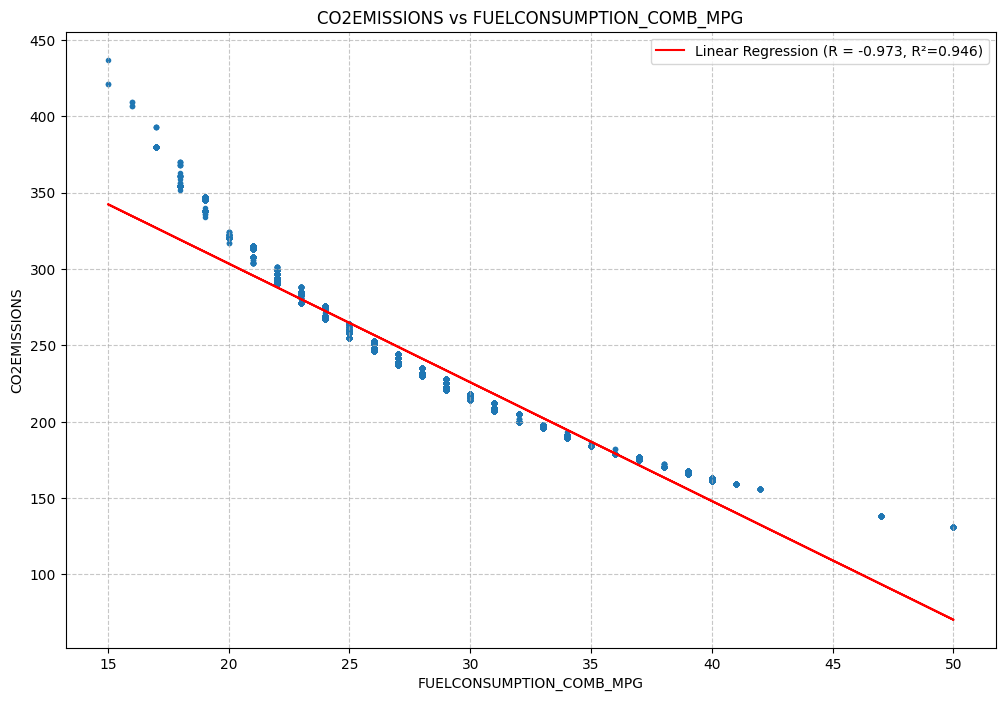

In [37]:

# Linear Regression
slope, intercept, r_value, p_value, std_err = stats.linregress(fuel_comb_mpg, co2)

def myfunc(fuel_comb_mpg):
  return slope * fuel_comb_mpg + intercept

mymodel = list(map(myfunc, fuel_comb_mpg))


fig, axes = plt.subplots(figsize=(12, 8))
plt.scatter(fuel_comb_mpg, co2, marker = ".")
plt.title("CO2EMISSIONS vs FUELCONSUMPTION_COMB_MPG")
plt.xlabel("FUELCONSUMPTION_COMB_MPG")
plt.ylabel("CO2EMISSIONS")
plt.plot(fuel_comb_mpg, mymodel, color='red', label=f'Linear Regression (R = {r_value:.3f}, R²={r_value**2:.3f})')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Fuel Consumption in City vs CO2 Emission

The graph shows a positive correlation between the CO2 emission and the Fuel Consumption in City as the value of R is positive. an R-squared value of 0.986 means that 98.6% of the variability of the CO2 emission can be explained by the Fuel Consumption in City.

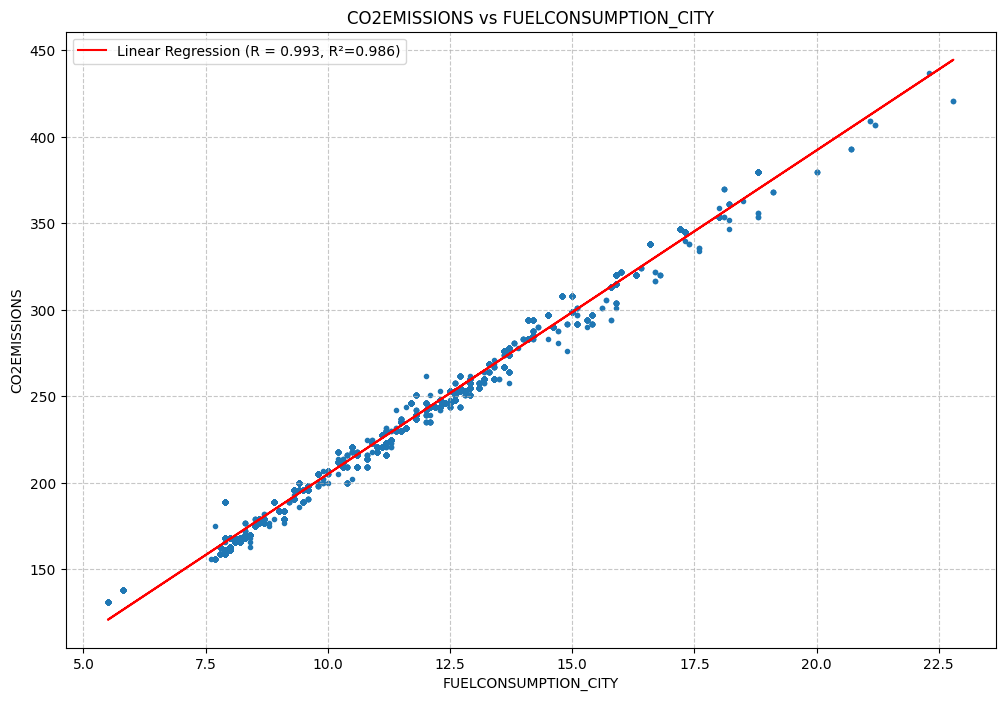

In [38]:
slope, intercept, r_value, p_value, std_err = stats.linregress(fuel_city, co2)

def myfunc(fuel_city):
  return slope * fuel_city + intercept

mymodel = list(map(myfunc, fuel_city))


fig, axes = plt.subplots(figsize=(12, 8))
plt.scatter(fuel_city, co2, marker = ".")
plt.title("CO2EMISSIONS vs FUELCONSUMPTION_CITY")
plt.xlabel("FUELCONSUMPTION_CITY")
plt.ylabel("CO2EMISSIONS")
plt.plot(fuel_city, mymodel, color='red', label=f'Linear Regression (R = {r_value:.3f}, R²={r_value**2:.3f})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Fuel Consumption in Highway vs CO2 Emission

The graph shows a positive correlation between the CO2 emission and the Fuel Consumption in Highway as the value of R is positive. an R-squared value of 0.947 means that 94.7% of the variability of the CO2 emission can be explained by the Fuel Consumption in Highway.

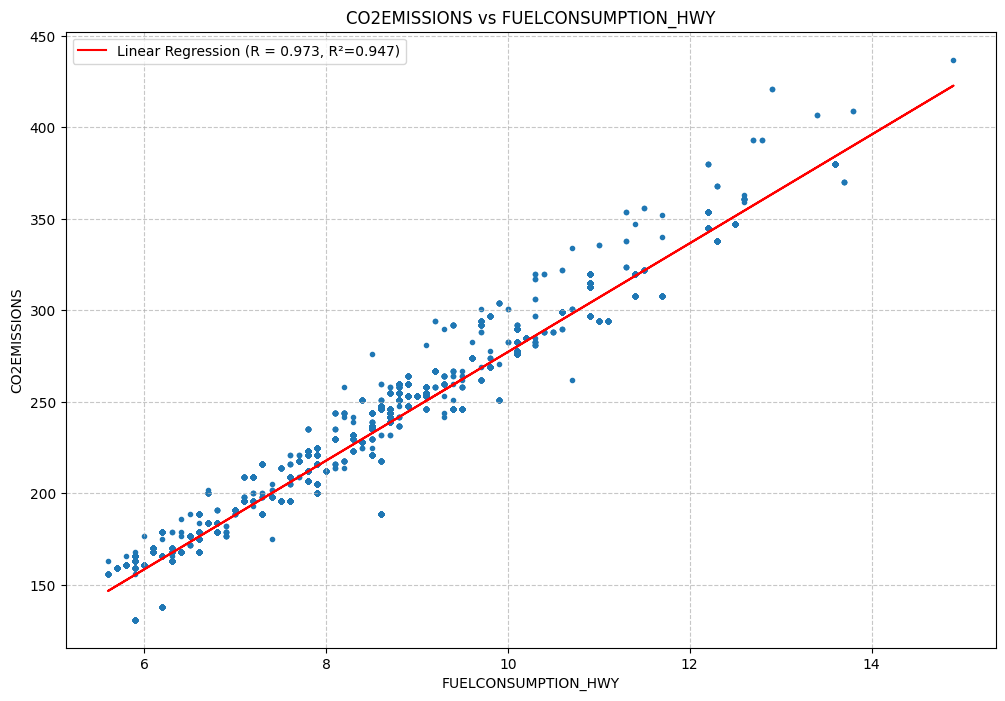

In [39]:
slope, intercept, r_value, p_value, std_err = stats.linregress(fuel_hwy, co2)

def myfunc(fuel_hwy):
  return slope * fuel_hwy + intercept

mymodel = list(map(myfunc, fuel_hwy))


fig, axes = plt.subplots(figsize=(12, 8))
plt.scatter(fuel_hwy, co2, marker = ".")
plt.title("CO2EMISSIONS vs FUELCONSUMPTION_HWY")
plt.xlabel("FUELCONSUMPTION_HWY")
plt.ylabel("CO2EMISSIONS")
plt.plot(fuel_hwy, mymodel, color='red', label=f'Linear Regression (R = {r_value:.3f}, R²={r_value**2:.3f})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Fuel Consumption Combine vs CO2 Emission

The graph shows a perfect positive correlation between the CO2 emission and the Fuel Consumption Combine as the value of R is 1. an R-squared value of 1.0 means that 100.0% of the variability of the CO2 emission can be explained by the Fuel Consumption Combine.

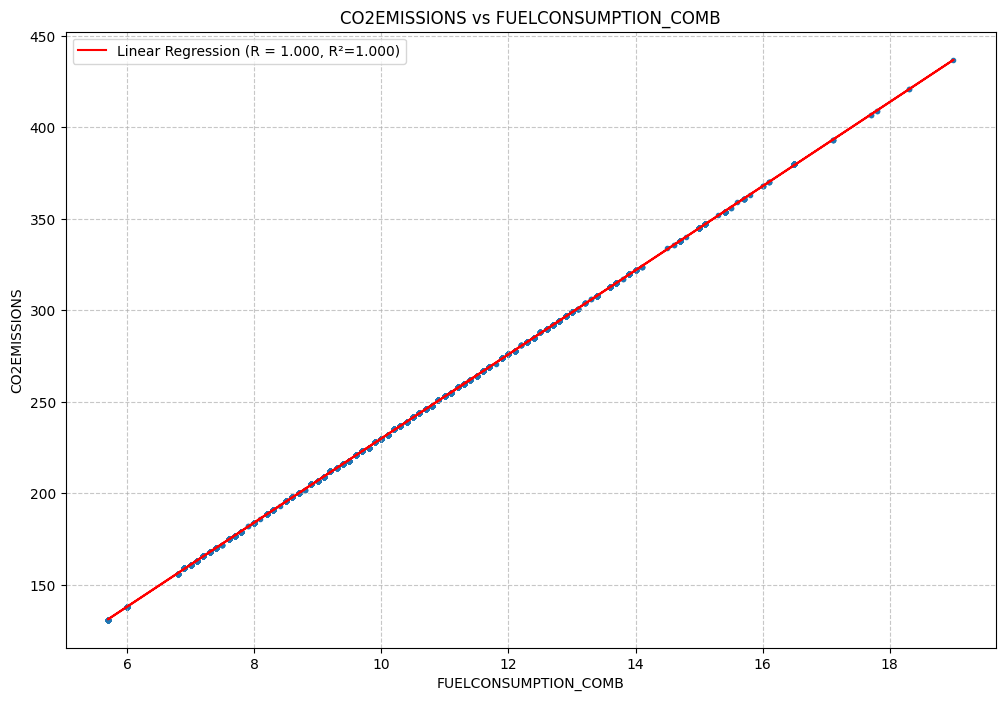

In [40]:
x = df["FUELCONSUMPTION_COMB"]
y = df["CO2EMISSIONS"]


slope, intercept, r_value, p_value, std_err = stats.linregress(fuel_comb, co2)

def myfunc(fuel_comb):
  return slope * fuel_comb + intercept

mymodel = list(map(myfunc, fuel_comb))



fig, axes = plt.subplots(figsize=(12, 8))
plt.scatter(fuel_comb, co2, marker = ".")
plt.title("CO2EMISSIONS vs FUELCONSUMPTION_COMB")
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("CO2EMISSIONS")
plt.plot(fuel_comb, mymodel, color='red', label=f'Linear Regression (R = {r_value:.3f}, R²={r_value**2:.3f})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Bar Plot Visualisation

This next section visualizes the `average CO2 emissions based on a categorical value` using a horizontal bar chart.

For this visualisation, the categorical value is the state(example). The same applies to all the grpahs after this. 

### Calculate the average CO2 emissions per state and sorting it in a descending order
`emission_state = df.groupby("STATE")["CO2EMISSIONS"].mean().sort_values(ascending=False)`

### Create a horizontal bar chart
`plt.figure(figsize=(10, 6))` determines the size of the graph.

`plt.barh(emission_state.index, emission_state.values, color='skyblue')` determines the size of the bar chart.

`plt.xlabel('Average CO2 Emissions (g/km)')` and `plt.ylabel('State')` determines the title of the x-axis and y-axis.

`plt.title('Average CO2 Emissions per State')` determines the title of the title of the graph.

`plt.gca().invert_yaxis()` invert the y-axis to show the state with the highest emissions at the top

### Show the plot
`plt.show()`


## Analyzing CO2 Emission based on State
Based on the graph the top three State that have the highest emissions are:
1. SARAWAK
2. W.P. KUALA LUMPUR
3. JOHOR

                    count        mean        std    min    25%    50%    75%  \
STATE                                                                          
JOHOR              1731.0  217.581745  48.598742  131.0  179.0  200.0  255.0   
KEDAH               462.0  204.614719  38.015507  156.0  175.0  191.0  238.5   
KELANTAN            240.0  194.983333  34.579599  159.0  168.0  184.0  209.0   
MELAKA              266.0  209.781955  37.705580  161.0  179.0  200.0  246.0   
NEGERI SEMBILAN     211.0  202.113744  35.328207  159.0  179.0  196.0  209.0   
PAHANG              175.0  195.937143  30.893059  161.0  175.0  191.0  209.0   
PERAK               630.0  207.495238  38.880508  131.0  184.0  196.0  221.0   
PERLIS               61.0  195.163934  40.895876  161.0  166.0  175.0  216.0   
PULAU PINANG        965.0  210.149223  44.969290  131.0  179.0  196.0  235.0   
SABAH               212.0  213.150943  55.747364  161.0  175.0  191.0  239.5   
SARAWAK             448.0  236.120536  5

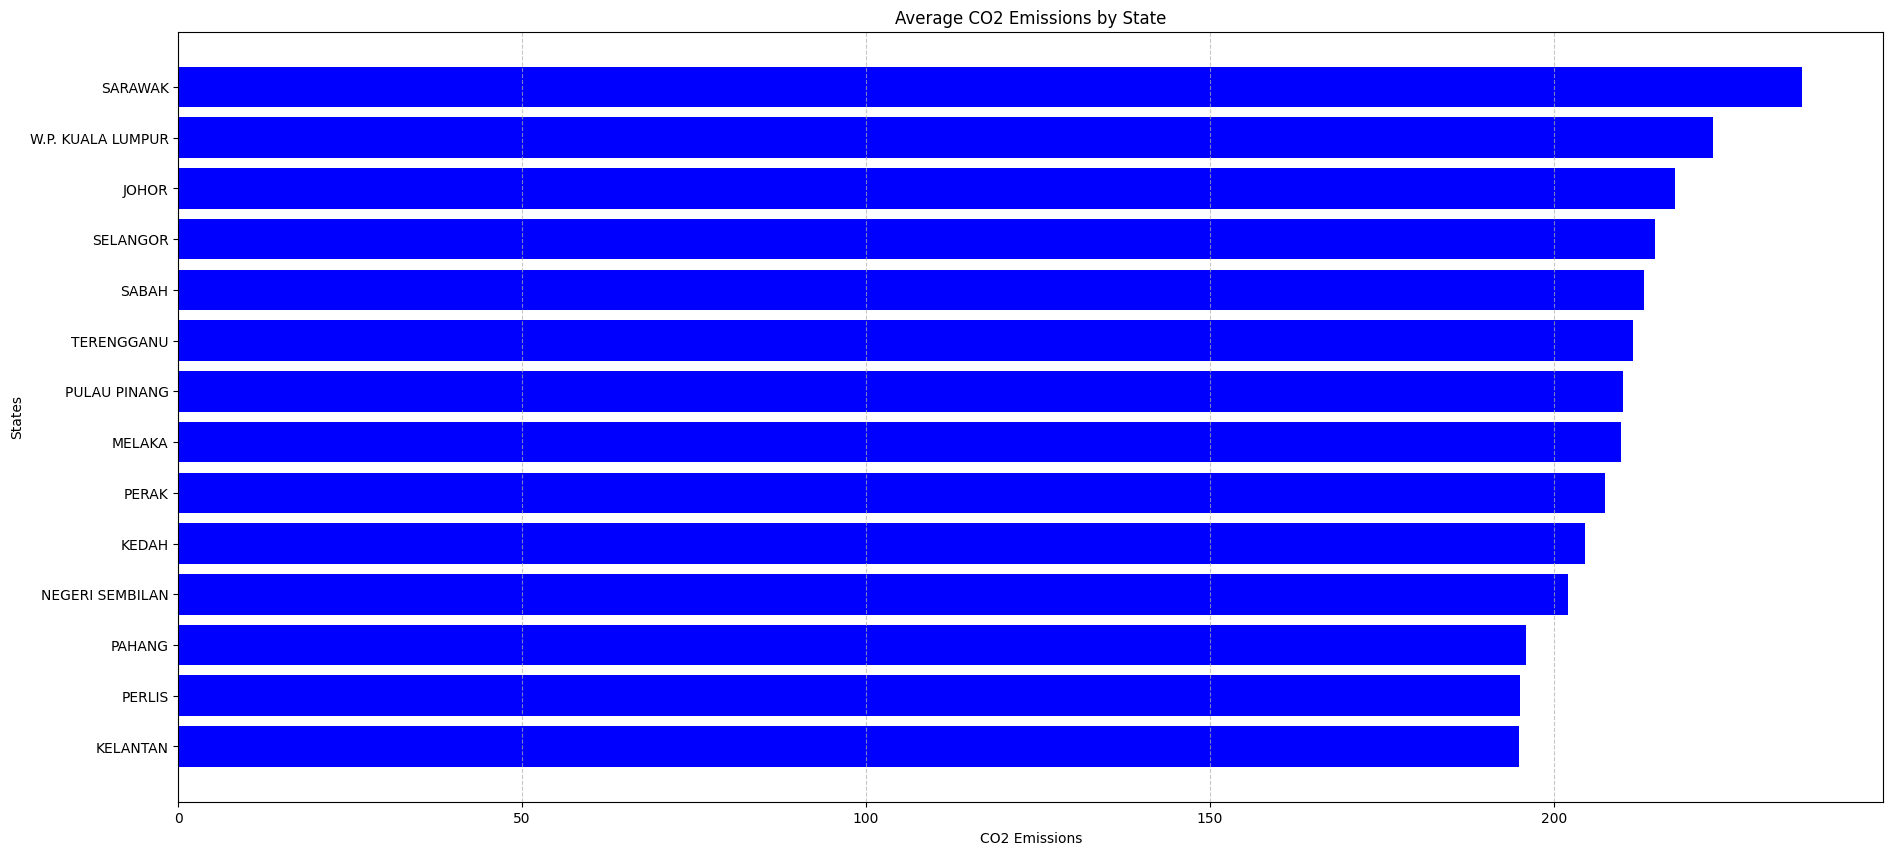

In [41]:
print(df.groupby("STATE")["CO2EMISSIONS"].describe())
emission_state = df.groupby("STATE")["CO2EMISSIONS"].mean().sort_values(ascending=False)
fig, axes = plt.subplots(figsize=(22, 10))

plt.title("Average CO2 Emissions by State")
plt.xlabel("CO2 Emissions")
plt.ylabel("States")
plt.barh(emission_state.index, emission_state.values.round(2), color="blue")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()
plt.show()


## Analyzing CO2 Emission based on Maker
Based on the graph the top three Maker that have the highest emissions are:
1. LAMBORGHINI
2. ROLCE-ROYCE
3. BENTLEY

                count        mean        std    min     25%    50%     75%  \
MAKER                                                                        
ACURA             1.0  255.000000        NaN  255.0  255.00  255.0  255.00   
ASTON-MARTIN      5.0  348.600000   9.889388  338.0  338.00  354.0  354.00   
AUDI            113.0  249.477876  45.092781  202.0  230.00  237.0  258.00   
BENTLEY          13.0  349.769231  41.055154  297.0  320.00  356.0  380.00   
BMW             287.0  252.923345  38.831099  200.0  209.00  255.0  260.00   
CHEVROLET         8.0  202.875000  41.367473  163.0  178.50  184.0  216.00   
DODGE            10.0  298.000000  23.428378  258.0  294.00  301.0  317.00   
FIAT             10.0  179.500000  12.249717  156.0  179.00  179.0  182.00   
FORD             53.0  256.132075  34.861836  166.0  244.00  244.0  292.00   
HONDA          2162.0  180.270120  22.442175  161.0  166.00  175.0  209.00   
HYUNDAI           5.0  232.400000  11.949895  214.0  230.00  232

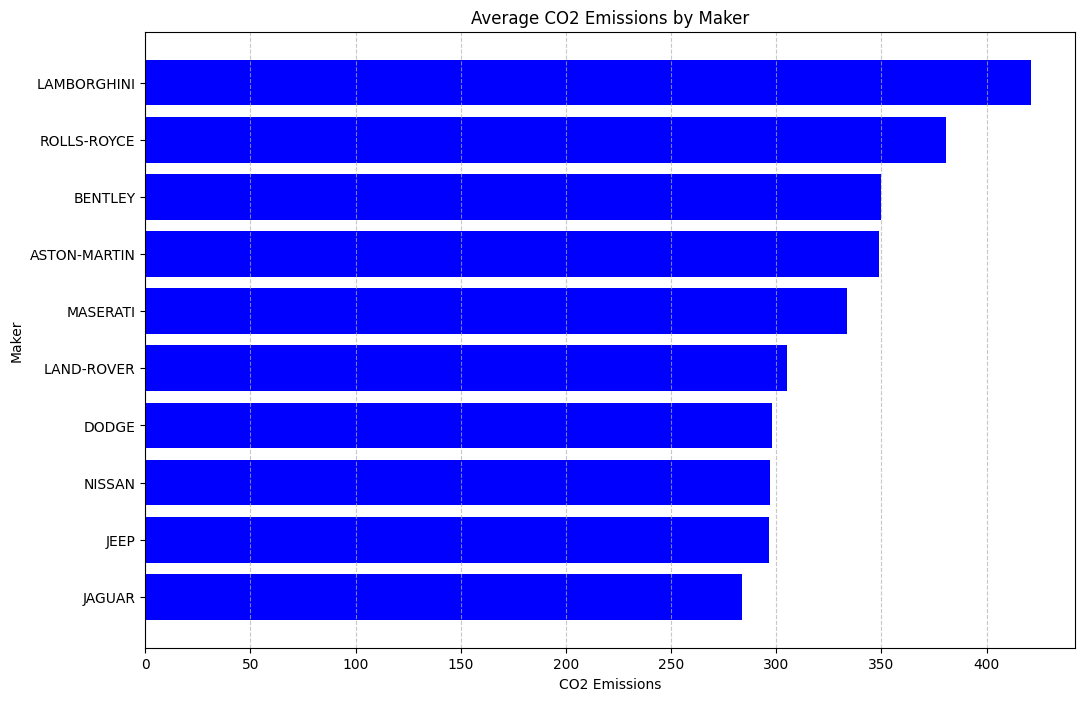

In [42]:
print(df.groupby("MAKER")["CO2EMISSIONS"].describe())
emission_maker = df.groupby("MAKER")["CO2EMISSIONS"].mean().sort_values(ascending=False).head(10)
fig, axes = plt.subplots(figsize=(12, 8))

plt.title("Average CO2 Emissions by Maker")
plt.xlabel("CO2 Emissions")
plt.ylabel("Maker")
plt.barh(emission_maker.index, emission_maker.round(2), color="blue")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()
plt.show()


## Analyzing CO2 Emission based on Model
For this code, as there are many different types of models from the dataset, only the top 10 highest average emission based on model is visualised as viusalising all of the model will make the graph look cluttered.

Additional code explanation for this section

`top_10_models = model_emission.sort_values(ascending=False).head(10)` takes in the top 10 models with the hisgest average emissiojn and stored in a variable. The variable will the be used to plot the graph same the previous ones.

Based on the graph the top three Model that have the highest emissions are:
1. MULSANNE
2. AVENTADOR COUPE
3. PHANTOM COUPE

                      count   mean        std    min    25%    50%    75%  \
MODEL                                                                       
500 ABARTH CABRIO       1.0  179.0        NaN  179.0  179.0  179.0  179.0   
500 ABARTH HATCHBACK    1.0  179.0        NaN  179.0  179.0  179.0  179.0   
500 CABRIO              2.0  174.0  11.313708  166.0  170.0  174.0  178.0   
500 CABRIO TURBO        1.0  179.0        NaN  179.0  179.0  179.0  179.0   
500 HATCHBACK           2.0  169.0  18.384776  156.0  162.5  169.0  175.5   
...                     ...    ...        ...    ...    ...    ...    ...   
XV CROSSTREK AWD       40.0  204.0   8.101915  196.0  196.0  204.0  212.0   
YARIS                 392.0  165.5   2.503195  163.0  163.0  165.5  168.0   
Z4 sDRIVE28i           26.0  204.5   4.589118  200.0  200.0  204.5  209.0   
Z4 sDRIVE35i           26.0  265.5  12.747549  253.0  253.0  265.5  278.0   
Z4 sDRIVE35is          13.0  278.0   0.000000  278.0  278.0  278.0  278.0   

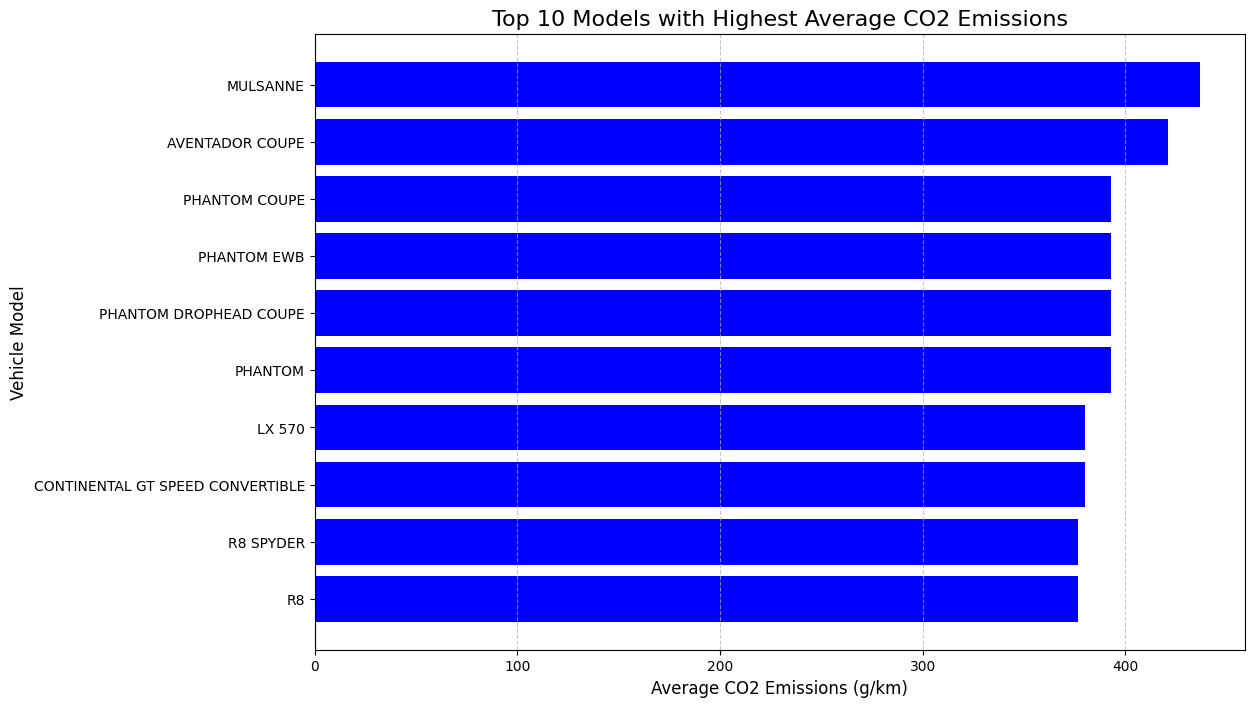

In [43]:
print(df.groupby("MODEL")["CO2EMISSIONS"].describe())
model_emission = df.groupby("MODEL")["CO2EMISSIONS"].mean()
top_10_models = model_emission.sort_values(ascending=False).head(10)

fig, axes = plt.subplots(figsize=(12, 8))

plt.barh(top_10_models.index, top_10_models.round(2), color='blue')
plt.gca().invert_yaxis()
plt.title("Top 10 Models with Highest Average CO2 Emissions", fontsize=16)
plt.xlabel("Average CO2 Emissions (g/km)", fontsize=12)
plt.ylabel("Vehicle Model", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

### Analyze CO2 Emissions by Transmission Type
Based on the graph the top three Transmission that have the highest emissions are:
1. A7
2. A8
3. AM6

The type of transmission affects the numbe of emissions produced. Automatic transmissions, particularly older models, tend to be less efficient than manual transmissions, leading to higher fuel consumption and consequently, more CO2 emissions. However, modern automatic transmissions, especially continuously variable transmissions (CVTs) and those with more gears, have improved significantly in efficiency and can sometimes even outperform manual transmissions in terms of emissions. 

               count        mean        std    min     25%    50%     75%  \
TRANSMISSION                                                                
A4             230.0  170.734783   7.530092  168.0  168.00  168.0  168.00   
A5             577.0  219.086655  24.442665  172.0  209.00  216.0  216.00   
A6            2241.0  203.269523  22.387528  166.0  191.00  200.0  207.00   
A7               6.0  370.333333  40.063283  336.0  340.50  354.0  404.25   
A8             822.0  291.217762  34.817639  209.0  276.00  299.0  315.00   
A9               8.0  242.625000  15.491357  218.0  231.50  245.0  251.50   
AM6             40.0  289.700000  17.673970  200.0  288.00  297.0  297.00   
AM7            758.0  252.617414  20.192438  232.0  237.00  246.0  260.00   
AS5              1.0  269.000000        NaN  269.0  269.00  269.0  269.00   
AS6           1656.0  230.394324  46.459309  159.0  196.00  223.0  269.00   
AS7            327.0  200.752294  31.433196  179.0  179.00  212.0  212.00   

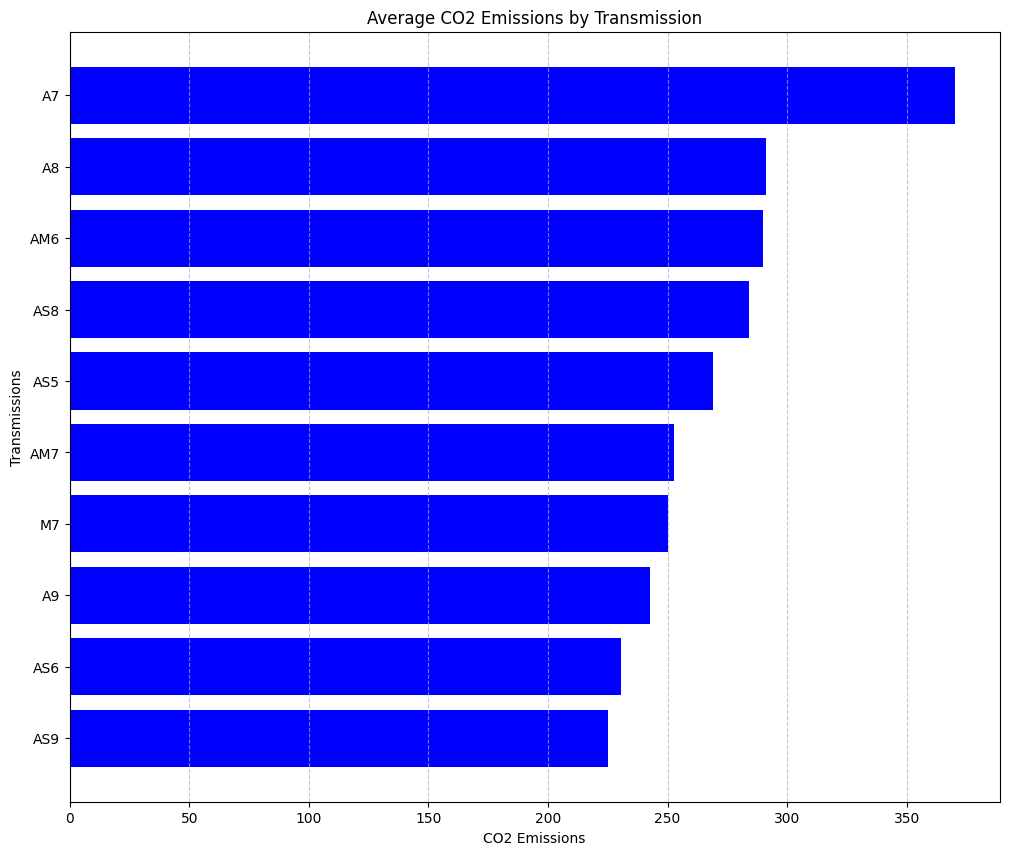

In [44]:

print(df.groupby("TRANSMISSION")["CO2EMISSIONS"].describe())
emission_trans = df.groupby(["TRANSMISSION"])["CO2EMISSIONS"].mean().sort_values(ascending=False).head(10)
fig, axes = plt.subplots(figsize=(12, 10))

plt.title("Average CO2 Emissions by Transmission")
plt.xlabel("CO2 Emissions")
plt.ylabel("Transmissions")
plt.barh(emission_trans.index, emission_trans.round(2), color="blue")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()
plt.show()


### Analyze CO2 Emission by Cylinder and Engine Size

As `ENGINESIZE` and `CYLINDERS` generally increase, the average `CO2EMISSIONS` also tend to increase. For example, vehicles with an `ENGINESIZE` of 1.4 L and 4 `CYLINDERS` have an average of 178 g/km of CO₂ emissions, while those with an `ENGINESIZE` of 6.8 L and 8 `CYLINDERS` have a higher average of 437 g/km of CO₂ emissions.

                       count        mean        std    min     25%    50%  \
ENGINESIZE CYLINDERS                                                        
1.4        4            14.0  178.071429  11.097223  156.0  177.50  179.0   
1.5        4           402.0  165.723881   2.869719  163.0  163.00  168.0   
1.6        4          3738.0  190.450776   9.846282  168.0  184.00  191.0   
1.8        4          1716.0  167.865385   7.130516  156.0  161.00  166.0   
2.0        4          1624.0  206.169951  28.017962  159.0  184.00  209.0   
2.4        4           587.0  215.563884  10.594798  209.0  209.00  216.0   
2.5        4           485.0  189.618557  26.363967  131.0  170.00  198.0   
           5            62.0  218.548387   4.119834  216.0  216.00  218.0   
           6           219.0  228.333333   7.559752  223.0  223.00  223.0   
3.0        6           437.0  271.382151  13.314576  251.0  260.00  278.0   
3.2        6             4.0  252.500000  10.661457  242.0  246.50  250.5   

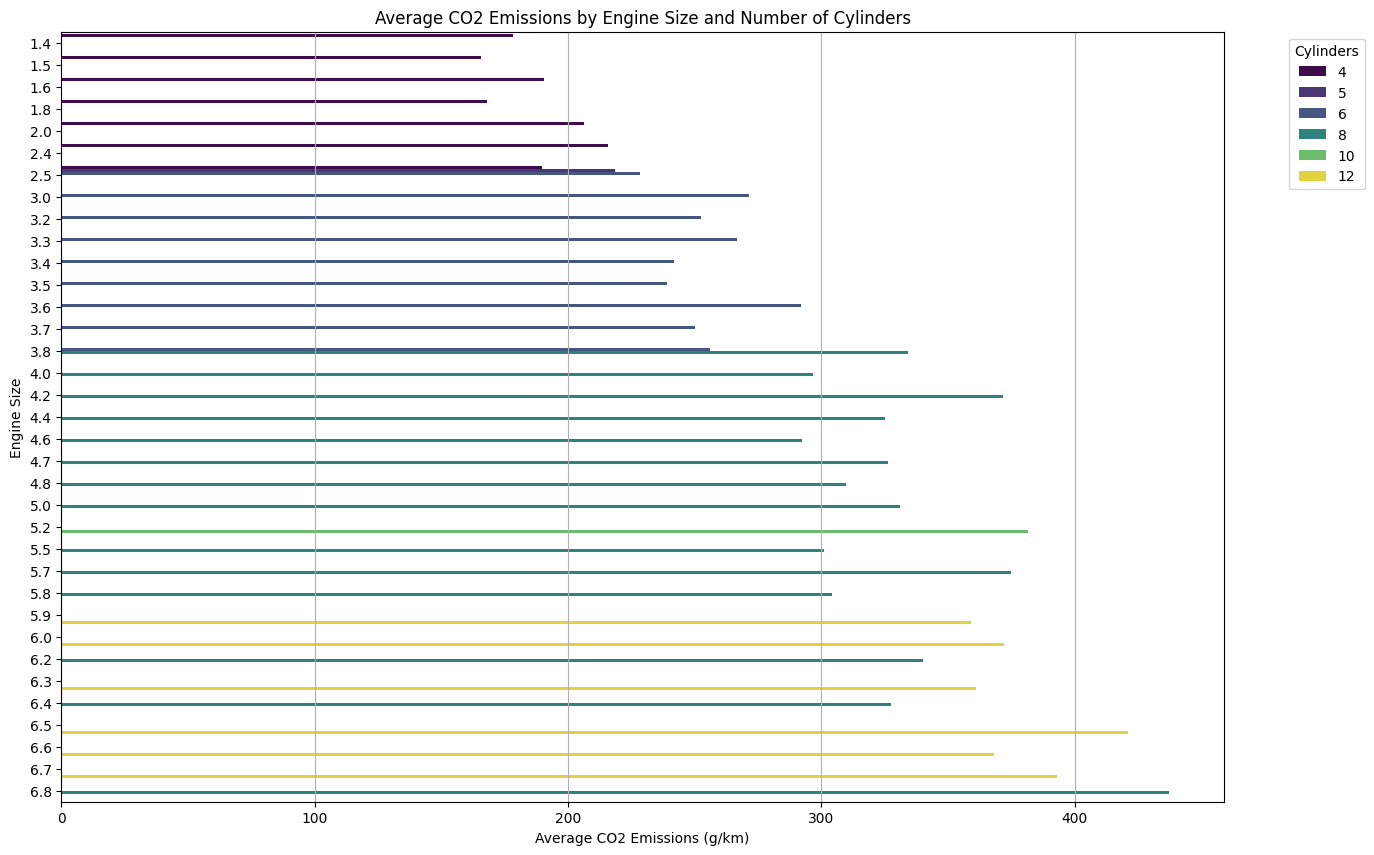

In [45]:
print(df.groupby(['ENGINESIZE', 'CYLINDERS'])['CO2EMISSIONS'].describe())

avg_co2_by_engine_specs = df.groupby(['ENGINESIZE', 'CYLINDERS'])['CO2EMISSIONS'].mean().reset_index()
# Ensure avg_co2_by_engine_specs is sorted for better visualization
avg_co2_by_engine_specs_sorted = avg_co2_by_engine_specs.sort_values(by=['ENGINESIZE', 'CYLINDERS'])

plt.figure(figsize=(15, 10)) # Adjust figure size for better readability of horizontal bars
sns.barplot(data=avg_co2_by_engine_specs_sorted, x='CO2EMISSIONS', y='ENGINESIZE', hue='CYLINDERS', palette='viridis', orient='h')
plt.title('Average CO2 Emissions by Engine Size and Number of Cylinders')
plt.xlabel('Average CO2 Emissions (g/km)')
plt.ylabel('Engine Size')
# No rotation needed for y-axis labels
plt.grid(axis='x') # Grid on x-axis for horizontal bars
plt.legend(title='Cylinders', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


# Machine Learning: Clustering with K-Means and PCA

This Python code performs **unsupervised machine learning** using the K-Means algorithm to group vehicles based on their specifications. It uses a combination of numerical features (`ENGINESIZE`, `CYLINDERS`, `FUELCONSUMPTION_COMB`, `CO2EMISSIONS`) and categorical features (`VEHICLECLASS`, `TRANSMISSION`, `FUEL_TYPE`). The goal is to identify patterns or groupings among vehicles with similar characteristics by projecting the data into a 2D space using PCA and then applying K-Means clustering.

### Data Preprocessing

Categorical features are first encoded into numeric format using `LabelEncoder`, allowing them to be used in mathematical operations. These encoded categorical values are then combined with the numerical features into a single feature set. To ensure all features contribute equally during clustering, the dataset is standardized using `StandardScaler`, which rescales the values to have a mean of 0 and standard deviation of 1.

### Dimensionality Reduction with PCA

To simplify the dataset and improve cluster visualization, **Principal Component Analysis (PCA)** is applied to reduce the data to two principal components. PCA projects the high-dimensional data into a lower-dimensional space while preserving as much of the original variance as possible. This not only reduces noise but also allows for a 2D plot to visualize the results of the clustering.

### Applying K-Means Clustering

After reducing the dataset to 2D, the **KMeans** algorithm is applied with `n_clusters=2`, which partitions the data into two clusters by minimizing intra-cluster variance. The algorithm starts by selecting two initial centroids and then iteratively adjusts them to find the best grouping of data points. The resulting cluster labels are stored and also used for visualization.

### Evaluating Clustering Performance

Three different metrics are used to evaluate the clustering quality: `silhouette_score`, which measures how similar an object is to its own cluster compared to other clusters (higher is better); `davies_bouldin_score`, which evaluates the average similarity ratio between clusters (lower is better); and `calinski_harabasz_score`, which measures the ratio of between-cluster dispersion to within-cluster dispersion (higher is better). These metrics provide insight into how well-separated and compact the clusters are.

### Cluster Visualization

The clustering results are visualized using a **scatter plot** of the two PCA components, with each point colored based on its assigned cluster. Red "X" markers indicate the centroids of each cluster. The plot includes axis labels that show the percentage of total variance captured by each principal component, giving context to the dimensions of the plot. This visual helps to understand the structure of the data and how the clustering algorithm has separated different types of vehicles.

### Adding Cluster Labels to the Dataset

Finally, the cluster assignments are added to the original DataFrame as a new column named `Cluster`. This allows for further analysis or segmentation of the dataset based on the discovered clusters, which can help identify common characteristics or trends among grouped vehicles.


Silhouette Score: 0.540
Davies-Bouldin Index: 0.724
Calinski-Harabasz Index: 19196.746


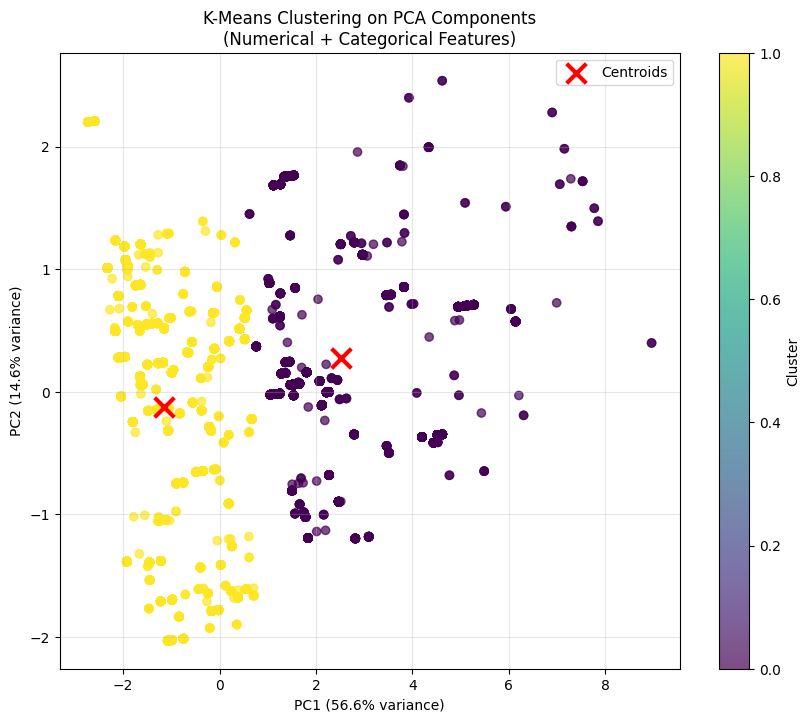

In [46]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Define Features
numerical_features = ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']
categorical_features = ['VEHICLECLASS', 'TRANSMISSION', 'FUEL_TYPE']

# Encode Categorical Features
df_encoded = df.copy()
label_encoders = {}
for feature in categorical_features:
    le = LabelEncoder()
    df_encoded[feature] = le.fit_transform(df[feature])
    label_encoders[feature] = le

# Combine Features
X_features = df_encoded[numerical_features + categorical_features]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# PCA 2D
pca = PCA(n_components=2)
X_2D = pca.fit_transform(X_scaled)

# KMeans Clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10) # 2 clusters
clusters = kmeans.fit_predict(X_2D)

labels = kmeans.labels_

# Calculate clustering performance metrics
silhouette_avg = silhouette_score(X_2D, labels)
davies_bouldin_avg = davies_bouldin_score(X_2D, labels)
calinski_harabasz_avg = calinski_harabasz_score(X_2D, labels)

print(f"Silhouette Score: {silhouette_avg:.3f}") # closer to 1 the better
print(f"Davies-Bouldin Index: {davies_bouldin_avg:.3f}") # the lower the better
print(f"Calinski-Harabasz Index: {calinski_harabasz_avg:.3f}") # the higher the better

# Clustering Visualization
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_2D[:, 0], X_2D[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('K-Means Clustering on PCA Components\n(Numerical + Categorical Features)')
plt.colorbar(scatter, label='Cluster')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', marker='x', s=200, linewidths=3, label='Centroids')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Append Cluster Labels
df['Cluster'] = clusters


This plot shows the result of K-Means clustering (with 2 groups) applied to car data, which has been reduced to 2 dimensions using PCA. Each dot is a car, and the color shows which cluster it belongs to. The red X marks the center (centroid) of each cluster.

- Cluster 0 (purple) and Cluster 1 (yellow) are mostly separated, showing that the grouping worked well.
- The horizontal axis (PC1) captures most of the data's variation (56.6%), helping to distinguish the clusters clearly.

### Evaluation Scores

- Silhouette Score = 0.540
    - Moderate to good separation between clusters (closer to 1 is better).
- Davies-Bouldin Index = 0.724
    - Low value means the clusters are tight and well separated (lower is better).
- Calinski-Harabasz Index = 19196.75
    - High value means the clusters are well defined (higher is better).

This shows that the clustering is effective which is the two groups are clearly different, and the evaluation scores confirm that the result is solid.


# Visualization

### Average Values per Cluster

This code computes the average engine size, CO2 emissions, and fuel consumption for each cluster. These values are collected in a summary DataFrame and reshaped using the `melt()` function to make the data suitable for plotting. The result is a **bar plot** that displays the average value of each metric per cluster. This helps in understanding how the clusters differ in terms of fundamental vehicle attributes like engine size and environmental impact.



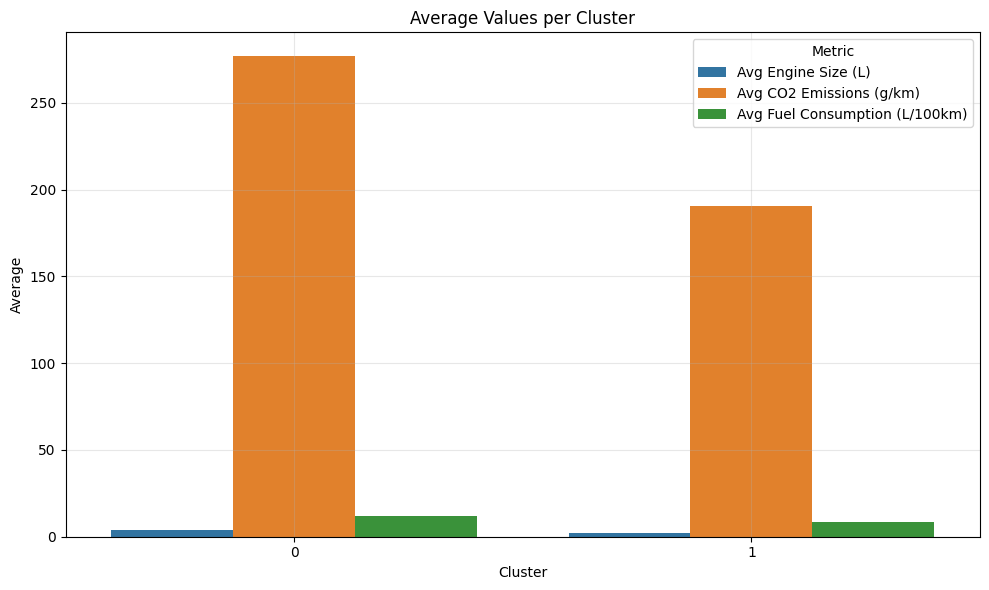

In [47]:
summary_data = []
for cluster in range(kmeans.n_clusters):
    cluster_data = df[df['Cluster'] == cluster]
    summary_data.append({
        'Cluster': cluster,
        'Avg Engine Size (L)': cluster_data['ENGINESIZE'].mean(),
        'Avg CO2 Emissions (g/km)': cluster_data['CO2EMISSIONS'].mean(),
        'Avg Fuel Consumption (L/100km)': cluster_data['FUELCONSUMPTION_COMB'].mean()
    })

summary_df = pd.DataFrame(summary_data)

# Melt for easier plotting
summary_melted = summary_df.melt(id_vars='Cluster', var_name='Metric', value_name='Value')

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=summary_melted, x='Cluster', y='Value', hue='Metric')
plt.title('Average Values per Cluster')
plt.ylabel('Average')
plt.xlabel('Cluster')
plt.legend(title='Metric')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The result shows that Cluster 0 has the highest average engine size, CO2 emissions, and fuel consumption, while Cluster 1 has the lowest. This indicates that Cluster 1 represents eco-conscious vehicles, while Cluster 0 may be more fuel-intensive or less environmentally conscious.

### Top 3 Makers per Cluster

This code generates **horizontal bar charts** that display the top 3 most common car manufacturers (`MAKER`) in each cluster. The plot is created using `matplotlib` and `seaborn`. It helps in identifying which manufacturers are most prevalent in each group, which can reflect brand positioning or specialization in certain vehicle types.

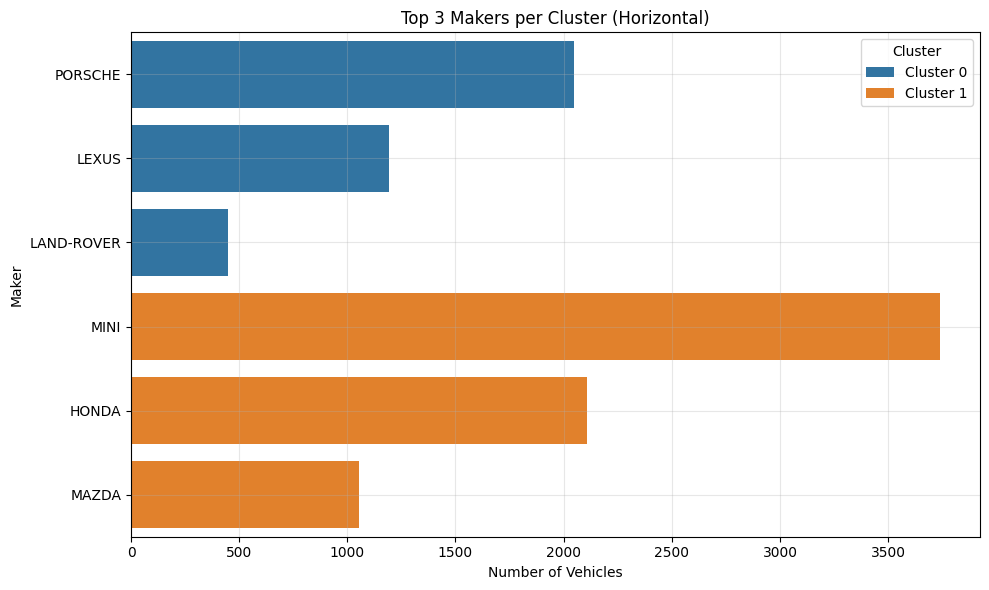

In [48]:
top_makers_data = []
for cluster in df['Cluster'].unique():
    cluster_data = df[df['Cluster'] == cluster]
    top_makers = cluster_data['MAKER'].value_counts().head(3)
    for maker, count in top_makers.items():
        top_makers_data.append({
            'Cluster': f'Cluster {cluster}',
            'Maker': maker,
            'Count': count
        })

top_makers_df = pd.DataFrame(top_makers_data)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_makers_df, y='Maker', x='Count', hue='Cluster', orient='h')
plt.title('Top 3 Makers per Cluster (Horizontal)')
plt.xlabel('Number of Vehicles')
plt.ylabel('Maker')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



The result shows that in Cluster 0, the most dominant maker is Porsche, followed by Lexus and Land Rover. This suggesting that this cluster may represent higher-end or performance-oriented vehicles. In contrast, Cluster 1 is dominated by MINI, with Honda and Mazda following, indicating that this cluster is likely composed of more compact, fuel-efficient, or mass-market vehicles.

### Top 3 Models for Each Top Maker per Cluster

For a deeper dive, this code identifies the top 3 car models for each of the top 3 makers in every cluster. A **grid of horizontal bar plots** is created using subplots with dimensions `(n_clusters x 3)`, where each subplot shows the most popular models by a specific maker within a specific cluster. This visualization offers a smooth view of product distribution and preferences among top manufacturers across clusters.

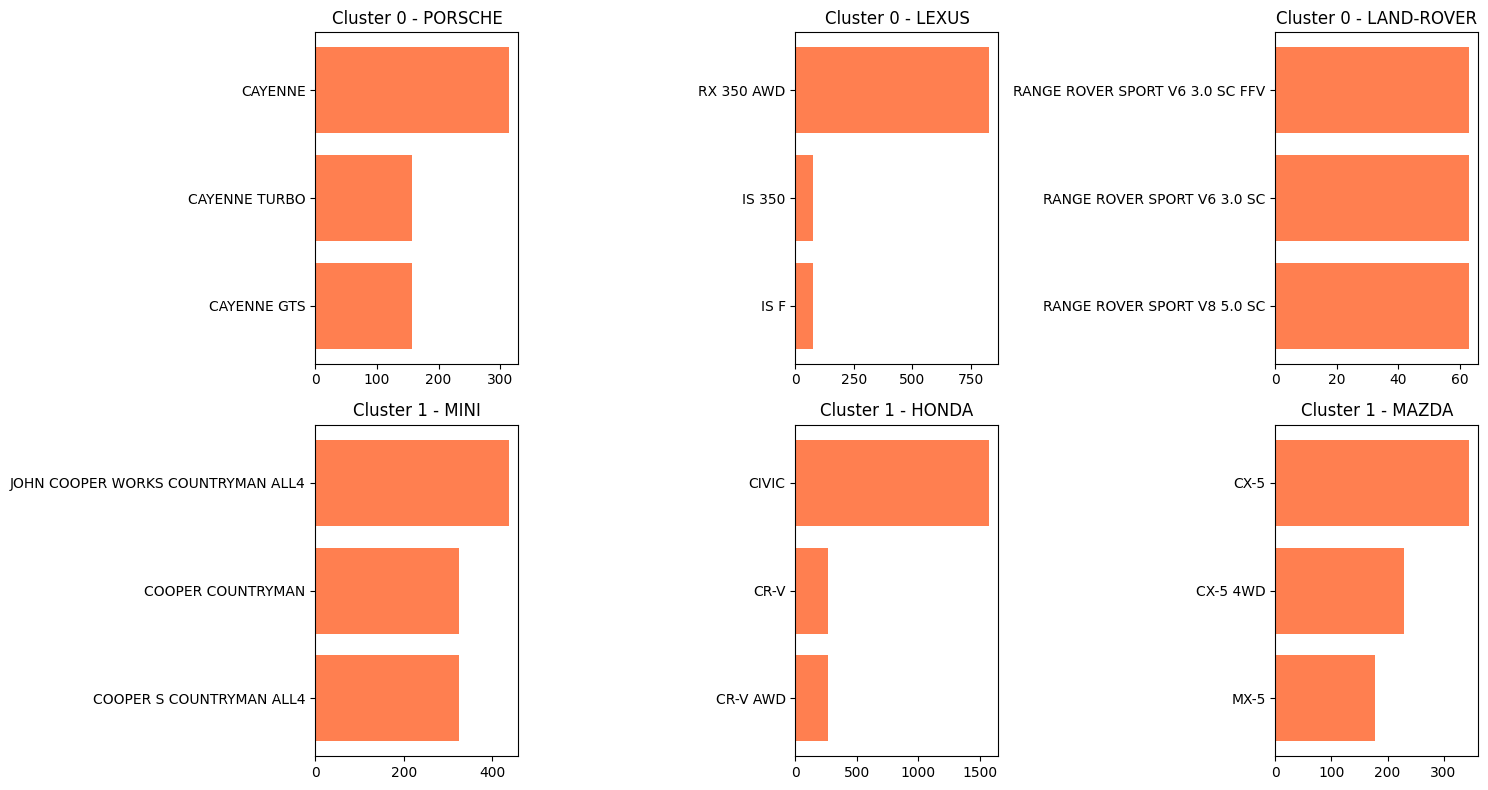

In [49]:
# Horizontal Bar Plot: Top 3 Models for Each Top Maker
fig, axes = plt.subplots(kmeans.n_clusters, 3, figsize=(15, 8))

for cluster in range(kmeans.n_clusters):
    cluster_data = df[df['Cluster'] == cluster]
    top_makers = cluster_data['MAKER'].value_counts().head(3).index

    for i, maker in enumerate(top_makers):
        maker_data = cluster_data[cluster_data['MAKER'] == maker]
        top_models = maker_data['MODEL'].value_counts().head(3)

        axes[cluster, i].barh(top_models.index, top_models.values, color='coral')
        axes[cluster, i].set_title(f'Cluster {cluster} - {maker}')
        axes[cluster, i].invert_yaxis()

plt.tight_layout()
plt.show()

The result shows: <br>

In Cluster 0, which includes premium or performance-oriented vehicles:

- Porsche is represented mainly by the Cayenne, Cayenne Turbo, and Cayenne GTS.

- Lexus is dominated by the RX 350 AWD, with minor contributions from IS 350 and IS F.

- Land Rover focuses heavily on Range Rover Sport variants, highlighting luxury SUV preferences in this cluster.

In Cluster 1, which appears to consist of more compact or family-oriented models:

- MINI's presence is mostly due to various Countryman models, with the John Cooper Works and Cooper S variants being most common.

- Honda is strongly dominated by the Civic, indicating a strong representation of compact sedans.

- Mazda is led by the CX-5 series (standard and 4WD) and the MX-5, suggesting a mix of crossovers and compact sports cars.


### Top 10 Models per Cluster

Finally, the last section highlights the **top 10 most common vehicle models** in each cluster regardless of maker. Models are grouped and counted using `groupby(['MAKER', 'MODEL'])`, and a combined label (`maker_model`) is created for clear presentation. A bar chart is plotted per cluster to showcase the most frequently occurring models, giving a strong indication of which specific vehicles dominate each cluster's profile.

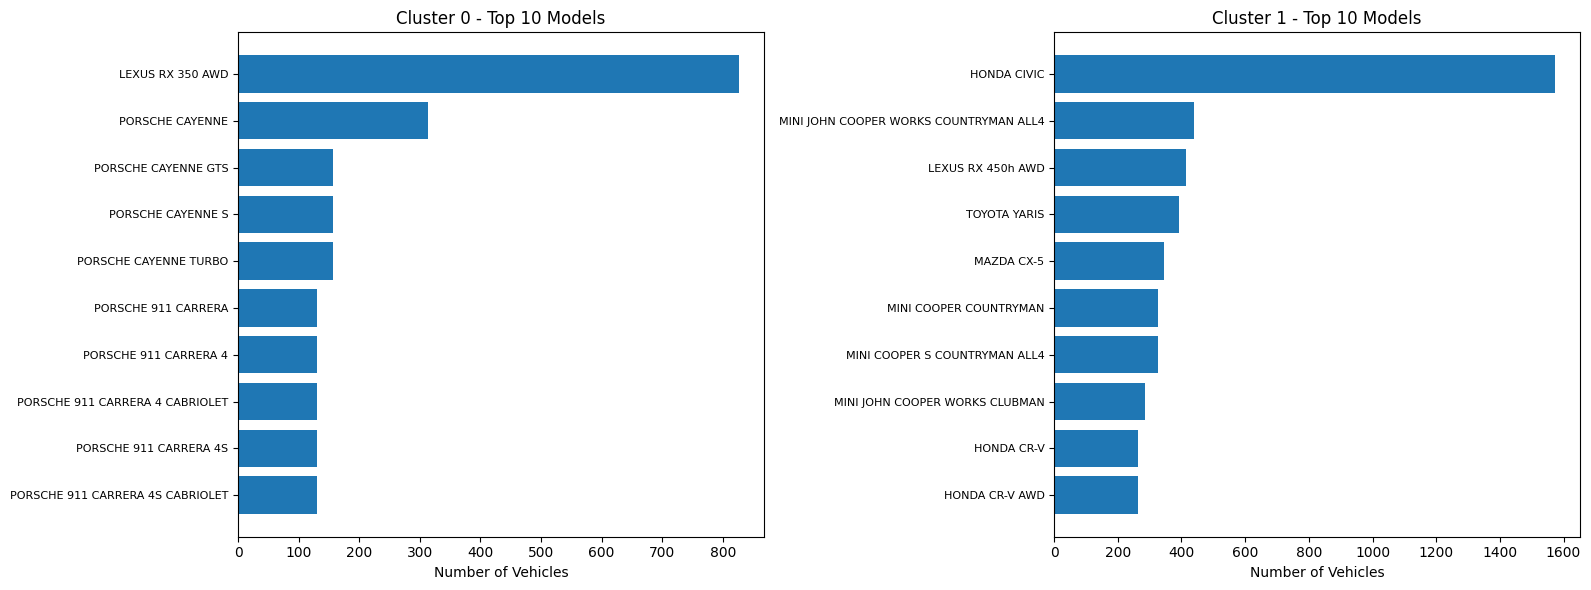

In [50]:
# Top 10 Model for each cluster
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for cluster in range(kmeans.n_clusters):
    cluster_data = df[df['Cluster'] == cluster]
    top_models = cluster_data.groupby(['MAKER', 'MODEL']).size().reset_index(name='count')
    top_models = top_models.nlargest(10, 'count')
    top_models['maker_model'] = top_models['MAKER'] + ' ' + top_models['MODEL']
    
    axes[cluster].barh(range(len(top_models)), top_models['count'])
    axes[cluster].set_yticks(range(len(top_models)))
    axes[cluster].set_yticklabels(top_models['maker_model'], fontsize=8)
    axes[cluster].set_xlabel('Number of Vehicles')
    axes[cluster].set_title(f'Cluster {cluster} - Top 10 Models')
    axes[cluster].invert_yaxis()

plt.tight_layout()
plt.show()

The result shows: <br>

Cluster 0 is dominated by the Lexus RX 350 AWD, which appears as the most frequent model. Following that are several Porsche models, including the Cayenne, Cayenne GTS, Cayenne S, and multiple variants of the Porsche 911 such as the Carrera, Carrera 4, and Cabriolet versions. This majority of Porsche and Lexus SUVs and sports cars suggests that Cluster 0 primarily represents luxury and performance-oriented vehicles.

Cluster 1 is led by the Honda Civic, which shows a dominant frequency compared to other models in this group. This cluster also includes a diverse mix of practical and fuel-efficient vehicles such as the MINI John Cooper Works Countryman, Toyota Yaris, Mazda CX-5, and Honda CR-V. Additionally, Lexus RX 450h AWD (a hybrid SUV) and other MINI Cooper variants are also present. These selections suggest that Cluster 1 is composed of more compact, accessible, and potentially environmentally friendly vehicles.